In [2]:
### Things to do - load in single cell data
### Align Cell Types
### Psuedobulk and limit data to cell types 
### check coexpression for every gene with every other gene - slow |


In [3]:
import pandas as pd
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse
from scipy import stats
sc.settings.verbosity = 2

In [4]:

maize_single_cell = sc.read_h5ad('/data/passala/Collaborator_Data/Maize_arabi_Jack_Collab/xu16_19_29_32_SeuratV4.0.1_finalclustermaize.h5ad')
arabi_single_cell = sc.read_h5ad('/data/passala/Collaborator_Data/Maize_arabi_Jack_Collab/xu_41_42.int_filter_recluster_final_forBen_arabi.h5ad')
maize_single_cell.var.set_index('_index', inplace= True)
arabi_single_cell.var.set_index('_index', inplace= True)

In [5]:
sc.pp.filter_genes(maize_single_cell, min_cells=5)
sc.pp.filter_genes(arabi_single_cell, min_cells=5)

filtered out 1346 genes that are detected in less than 5 cells
filtered out 1206 genes that are detected in less than 5 cells


In [6]:
maize_single_cell.obs

,orig.ident,nCount_RNA,nFeature_RNA,DataSet,integrated_snn_res.1,seurat_clusters,test_res.1,determinate,subcluster9,mygraph_res.1
AAACCCAAGAGTCACG-1_1,A,20391.0,6774,A,3,14,6,14,14,6
AAACCCACACTGGCCA-1_1,A,6045.0,3397,A,3,9,14,9_1,9_1,14
AAACGAAAGTGCAAAT-1_1,A,29559.0,7397,A,14,1,1,1,1,1
AAACGAAGTATCGTGT-1_1,A,11369.0,4750,A,4,2,7,2,2,7
AAAGAACAGGTGCTAG-1_1,A,37426.0,8552,A,5,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
TTTGGTTCAAACGAGC-1_4,D,22506.0,5823,D,9,8,13,8,8,13
TTTGGTTCAGTAGATA-1_4,D,22299.0,6393,D,3,6,11,6,6,11
TTTGGTTTCGAGTCCG-1_4,D,14269.0,5479,D,8,9,14,9_0,9_0,14
TTTGGTTTCGCTTTAT-1_4,D,12012.0,4898,D,8,9,14,9_0,9_0,14


In [7]:
(maize_single_cell.obs['subcluster9'] == maize_single_cell.obs['determinate']).sum()

9454

In [8]:
arabi_single_cell.obs['integrated_snn_res.0.75'] = arabi_single_cell.obs['integrated_snn_res.0.75'].astype(str)


In [9]:
list_of_not_correct_labels = ['percent.mt', 'integrated_snn_res.0.5','integrated_snn_res.1','integrated_snn_res.1.2','integrated_snn_res.1.5','integrated_snn_res.0.45','integrated_snn_res.0.25','integrated_snn_res.0.7','integrated_snn_res.0.8','integrated_snn_res.0.65','integrated_snn_res.0.6','integrated_snn_res.0.55','integrated_snn_res.0.53','integrated_snn_res.0.52','integrated_snn_res.0.54','integrated_snn_res.2']

In [10]:
arabi_single_cell.obs = arabi_single_cell.obs.drop(columns= list_of_not_correct_labels)

In [11]:
arabi_single_cell.obs

,orig.ident,nCount_RNA,nFeature_RNA,RNA_snn_res.0.5,seurat_clusters,source,integrated_snn_res.0.75
AAACCCAAGGGATGTC-1_1,xu41_l151,11263.0,3178,4,3,xu41,0
AAACCCACAAATAGCA-1_1,xu41_l151,4717.0,2372,0,6,xu41,5
AAACCCACAGAGAATT-1_1,xu41_l151,2507.0,1423,1,7,xu41,13
AAACCCAGTCTCGGAC-1_1,xu41_l151,3596.0,1394,1,2,xu41,12
AAACCCAGTGAAGCGT-1_1,xu41_l151,3468.0,1133,5,1,xu41,9
...,...,...,...,...,...,...,...
TTTGTTGCAGAGTAAT-1_2,xu42_l151,23882.0,6459,2,2,xu42,12
TTTGTTGCATGTCAGT-1_2,xu42_l151,21439.0,5364,8,2,xu42,4
TTTGTTGTCGACACCG-1_2,xu42_l151,6479.0,2714,5,8,xu42,8
TTTGTTGTCGCCTATC-1_2,xu42_l151,2002.0,1211,2,2,xu42,4


In [12]:
arabi_single_cell.obs['integrated_snn_res.0.75'].value_counts() ### 

0     1893
1     1832
2     1747
3     1513
4     1489
5     1428
6     1323
7     1205
8     1200
9     1193
10    1135
11     913
12     837
13     833
14     815
15     651
16     159
17      58
Name: integrated_snn_res.0.75, dtype: int64

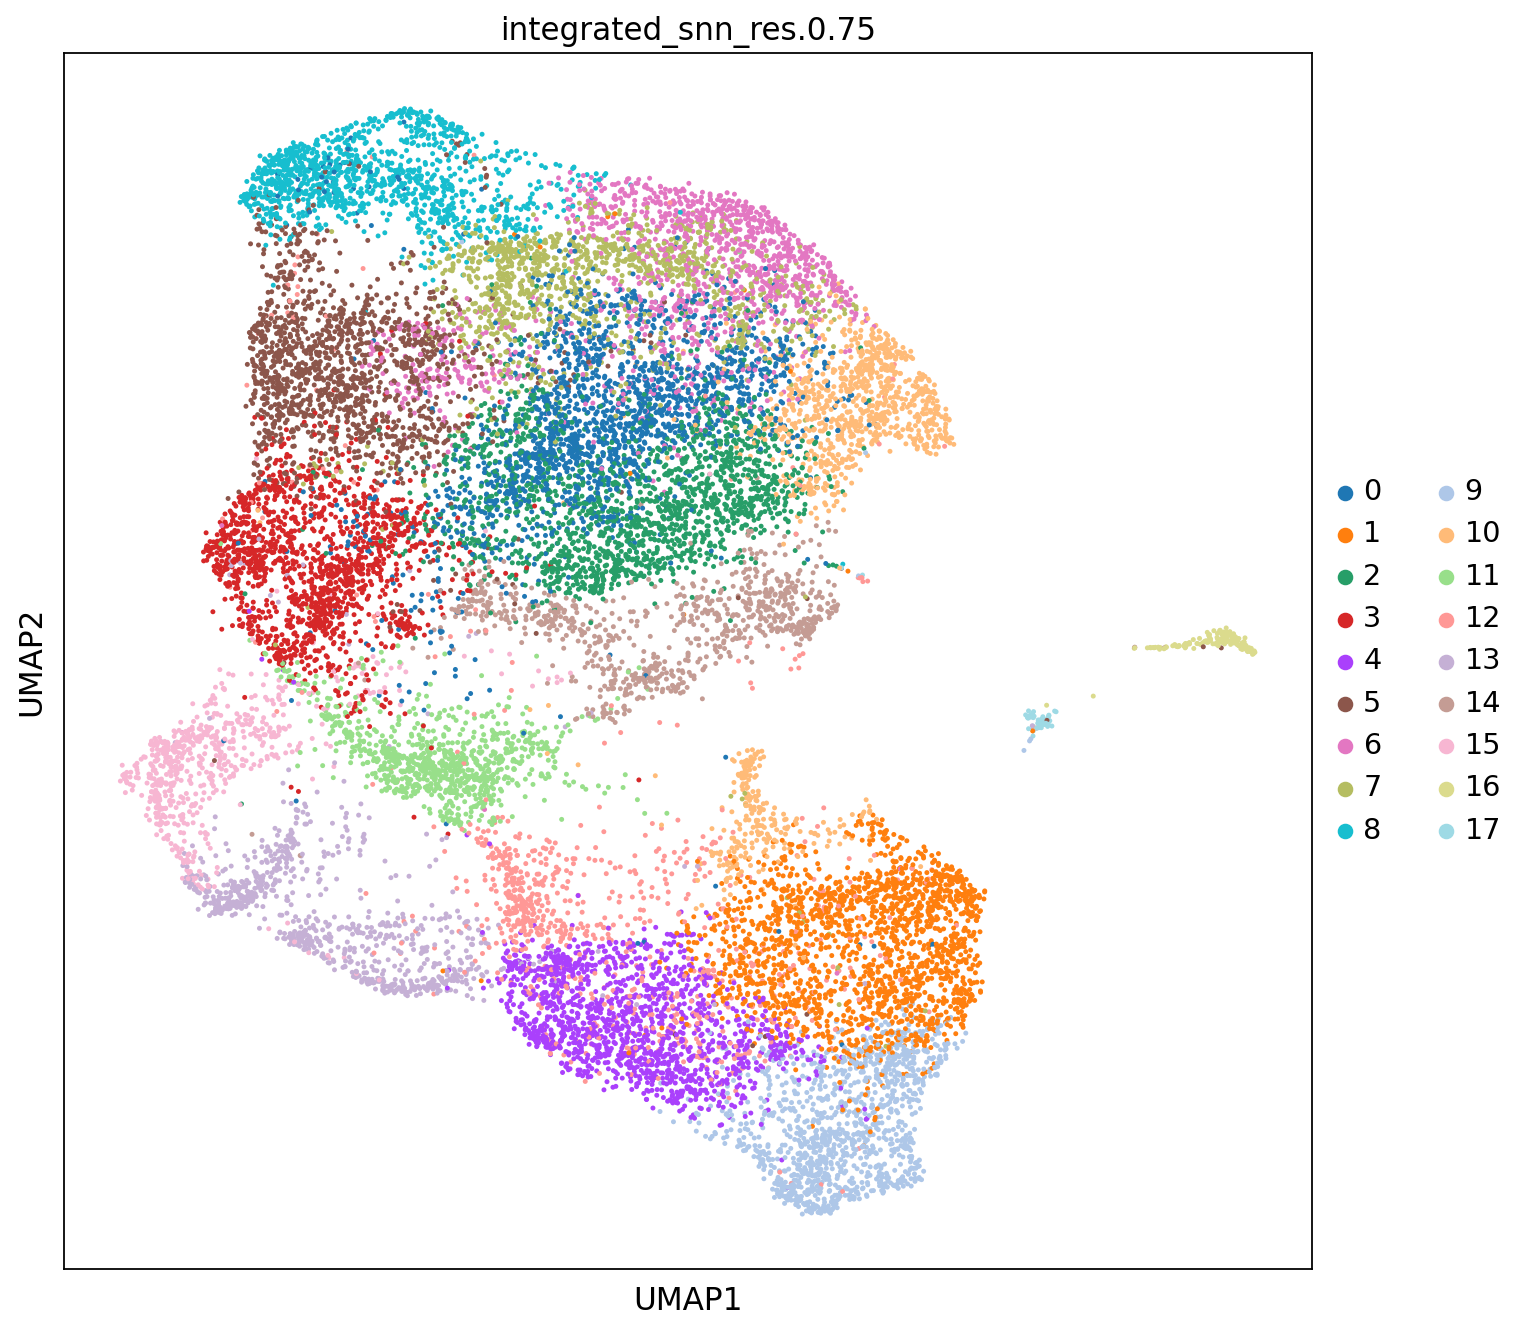

In [13]:
sc.set_figure_params(figsize=(10, 10))
sc.pl.umap(arabi_single_cell, color=['integrated_snn_res.0.75'], use_raw= False, s = 20) ### This is the correct one

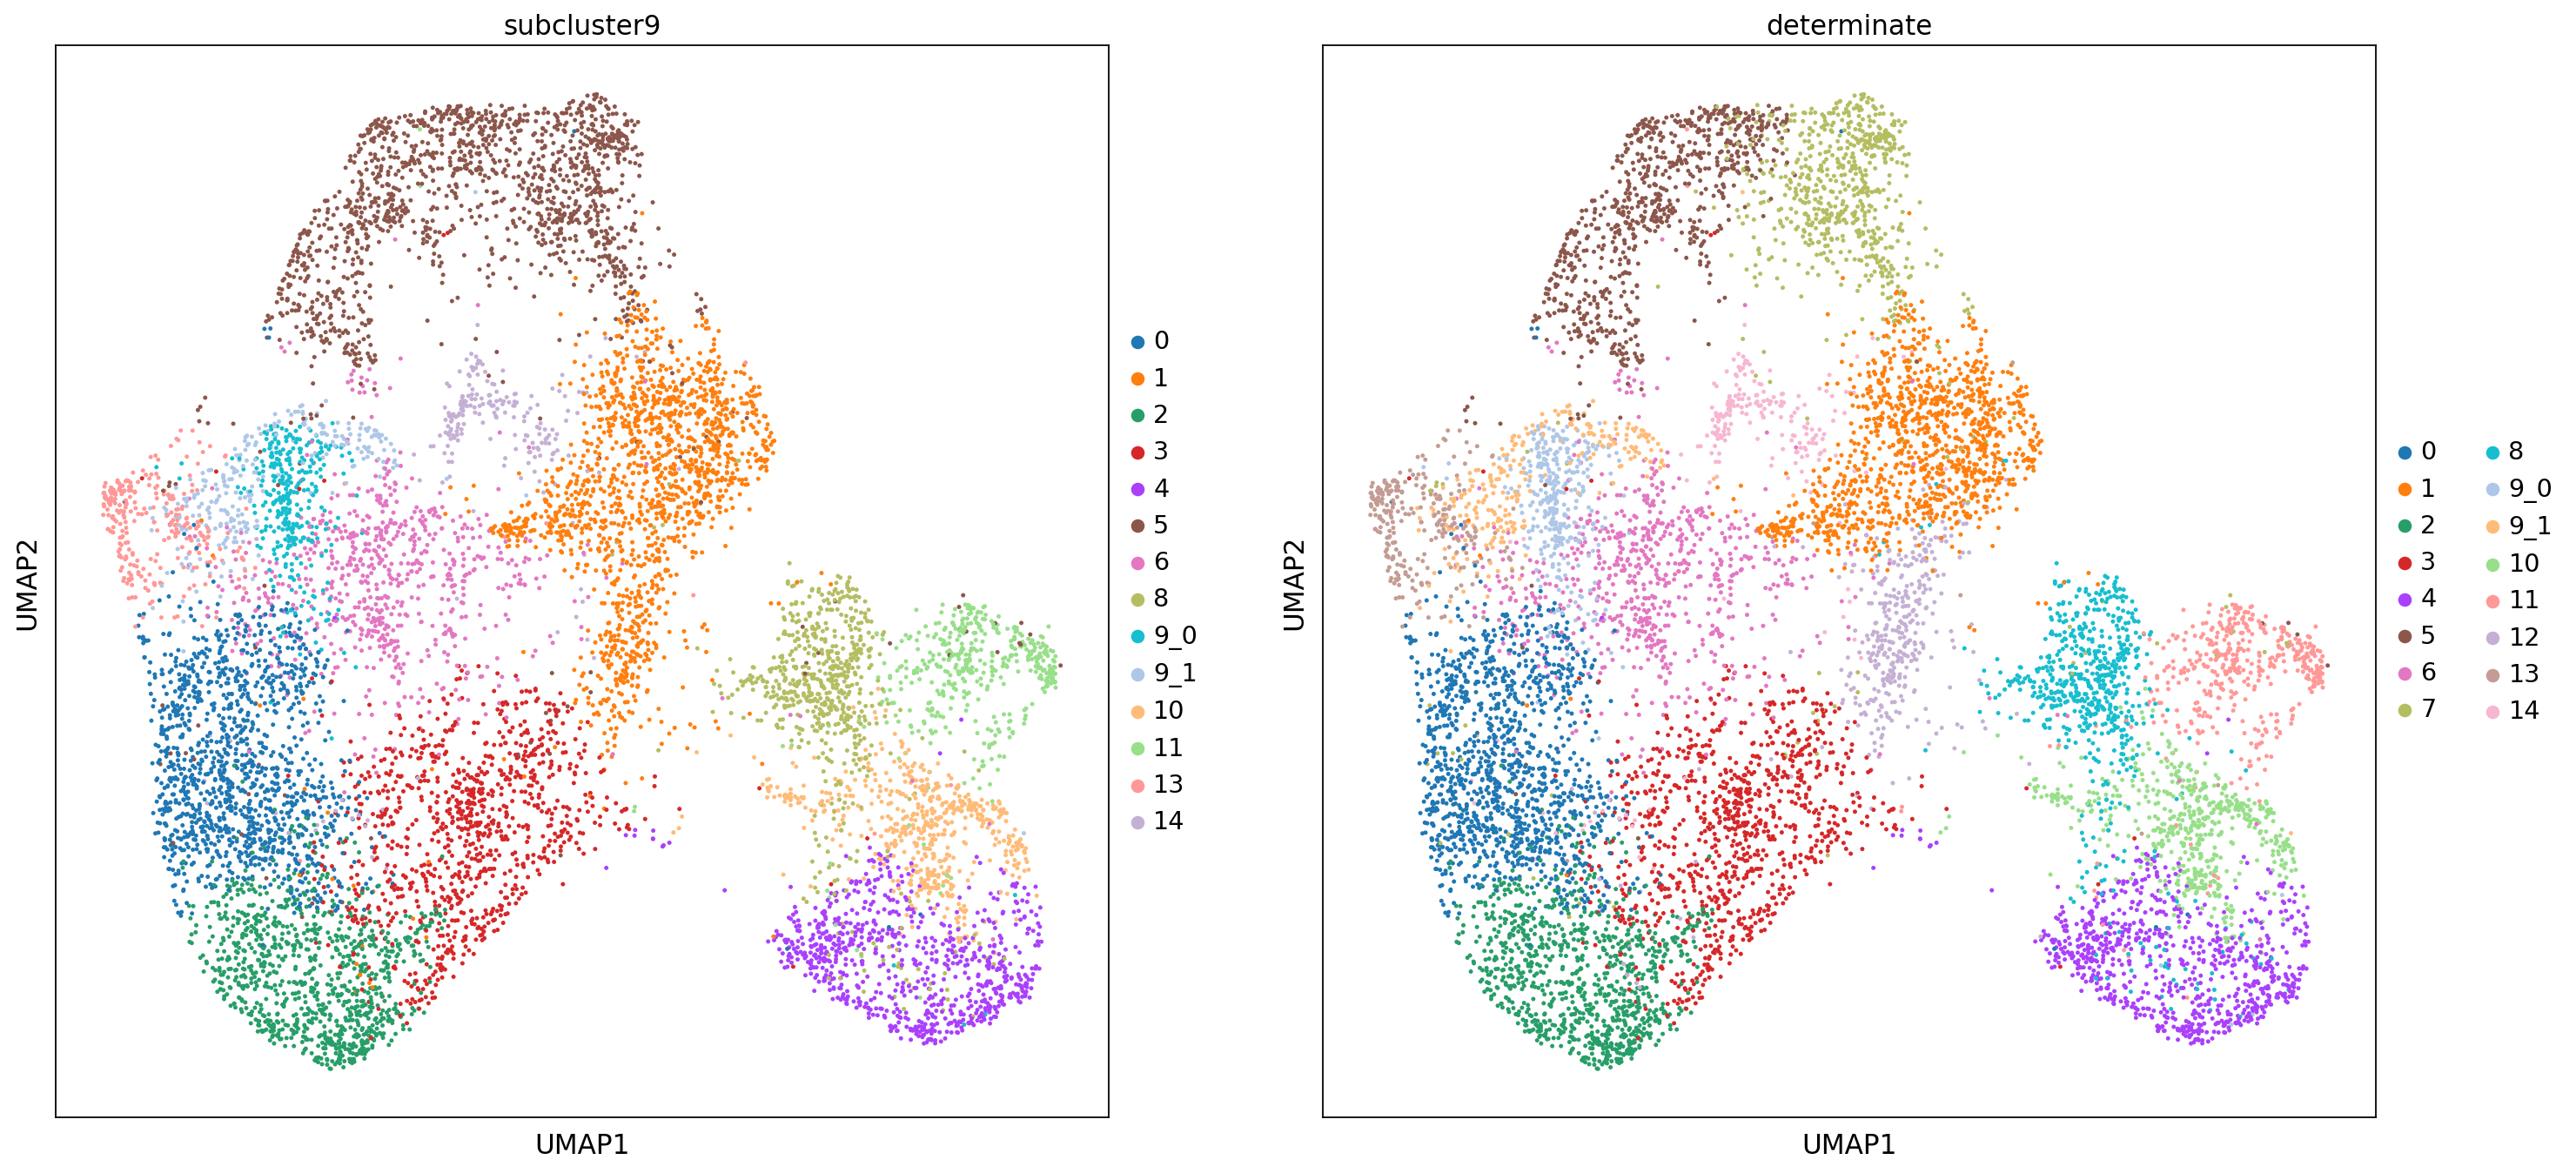

In [14]:
sc.pl.umap(maize_single_cell, color=['subcluster9','determinate'], use_raw= False, s = 20) ### Subcluster9 is correct

In [15]:
cell_type_mapper_for_maize = {'11':'Cell Cycle G2M Epi',
    '5':'Cell Cycle G2M Non-Epi',
    '8':'Cell Cycle S Epi',
    '1':'Cell Cycle S NonEpi',
    '0':'Cortex',
    '2':'Cortex',
    '14':'Vasculature',
    '3':'Central Zone',
    '6':'Central Zone',
    #'13':'Adaxial Meristem',
    '9_0':'Determinate Lateral Organ Non Epi',
    '4':'Determinate Lateral Organ Epi',
    #'10':'Meristem Epidermis'
    }
    

In [16]:
maize_single_cell.obs['Cell Type'] = maize_single_cell.obs['subcluster9'].map(cell_type_mapper_for_maize)

In [17]:
cell_mapper_for_arabi = {'13':'Cell Cycle G2M Epi',
    '15':'Cell Cycle G2M Non-Epi',
    '12':'Cell Cycle S Epi',
    '11':'Cell Cycle S NonEpi',
    '6':'Cortex',
    '7':'Cortex',
    '8':'Cortex',
    '2':'Vasculature',
    '14':'Vasculature',
    '16':'Vasculature',
    '17':'Vasculature',
    '0':'Central Zone',
    '10':'Central Zone',
    '5':'Determinate Lateral Organ Non Epi',
    '1':'Determinate Lateral Organ Epi',
    }

In [18]:
cell_type_number_mapper = {'Cell Cycle G2M Epi':0,
    'Cell Cycle G2M Non-Epi':1,
    'Cell Cycle S Epi':2,
    'Cell Cycle S NonEpi':3,
    'Cortex':4,
    'Vasculature':5,
    'Central Zone':6,
    'Determinate Lateral Organ Non Epi':7,
    'Determinate Lateral Organ Epi':8}

In [19]:
list_of_cell_types = ['Cell Cycle G2M Epi',
    'Cell Cycle G2M Non-Epi',
    'Cell Cycle S Epi',
    'Cell Cycle S NonEpi',
    'Cortex',
    'Vasculature',
    'Central Zone',
    'Determinate Lateral Organ Non Epi',
    'Determinate Lateral Organ Epi']
list_of_cell_types

['Cell Cycle G2M Epi',
 'Cell Cycle G2M Non-Epi',
 'Cell Cycle S Epi',
 'Cell Cycle S NonEpi',
 'Cortex',
 'Vasculature',
 'Central Zone',
 'Determinate Lateral Organ Non Epi',
 'Determinate Lateral Organ Epi']

In [20]:
arabi_single_cell.obs['Cell Type'] = arabi_single_cell.obs['integrated_snn_res.0.75'].map(cell_mapper_for_arabi)
arabi_single_cell.obs

,orig.ident,nCount_RNA,nFeature_RNA,RNA_snn_res.0.5,seurat_clusters,source,integrated_snn_res.0.75,Cell Type
AAACCCAAGGGATGTC-1_1,xu41_l151,11263.0,3178,4,3,xu41,0,Central Zone
AAACCCACAAATAGCA-1_1,xu41_l151,4717.0,2372,0,6,xu41,5,Determinate Lateral Organ Non Epi
AAACCCACAGAGAATT-1_1,xu41_l151,2507.0,1423,1,7,xu41,13,Cell Cycle G2M Epi
AAACCCAGTCTCGGAC-1_1,xu41_l151,3596.0,1394,1,2,xu41,12,Cell Cycle S Epi
AAACCCAGTGAAGCGT-1_1,xu41_l151,3468.0,1133,5,1,xu41,9,NaN
...,...,...,...,...,...,...,...,...
TTTGTTGCAGAGTAAT-1_2,xu42_l151,23882.0,6459,2,2,xu42,12,Cell Cycle S Epi
TTTGTTGCATGTCAGT-1_2,xu42_l151,21439.0,5364,8,2,xu42,4,NaN
TTTGTTGTCGACACCG-1_2,xu42_l151,6479.0,2714,5,8,xu42,8,Cortex
TTTGTTGTCGCCTATC-1_2,xu42_l151,2002.0,1211,2,2,xu42,4,NaN


In [21]:
labeled_arabi_single_cell = arabi_single_cell[~arabi_single_cell.obs['Cell Type'].isna(),:]
labeled_maize_single_cell = maize_single_cell[~maize_single_cell.obs['Cell Type'].isna(),:]


In [29]:
maize_clusters = list(set(maize_single_cell.obs['subcluster9']))
arabi_clusters =list(set(arabi_single_cell.obs['integrated_snn_res.0.75']))

In [30]:
all_maize_cluster_means = []

for cluster_id in maize_clusters:
    current_type_anndata = maize_single_cell[maize_single_cell.obs['subcluster9'] == cluster_id,:]
    all_gene_means = current_type_anndata.X.todense().mean(0).tolist()
    all_maize_cluster_means.extend(all_gene_means)

all_arabi_cluster_means = []

for cluster_id in arabi_clusters:
    current_type_anndata = arabi_single_cell[arabi_single_cell.obs['integrated_snn_res.0.75'] == cluster_id,:]
    all_gene_means = current_type_anndata.X.todense().mean(0).tolist()
    all_arabi_cluster_means.extend(all_gene_means)

psuedobulked_clusters_maize = pd.DataFrame(data = all_maize_cluster_means, index = maize_clusters, columns = maize_single_cell.var.index)
psuedobulked_clusters_arabi = pd.DataFrame(data = all_arabi_cluster_means, index = arabi_clusters, columns = labeled_arabi_single_cell.var.index)

In [31]:
psuedobulked_clusters_maize

_index,GRMZM2G059865,GRMZM2G093344,GRMZM2G306216,GRMZM2G104572,GRMZM5G822187,GRMZM2G023794,GRMZM2G471814,GRMZM2G330436,GRMZM2G032104,GRMZM2G333069,...,GRMZM2G002630,GRMZM2G068275,GRMZM2G307823,GRMZM5G875445,GRMZM2G337548,GRMZM2G343437,GRMZM2G177792,GRMZM2G061499,GRMZM2G071924,GRMZM2G450231
9_0,0.334105,0.015983,0.001387,0.000000,0.001503,0.005458,0.002053,0.146920,0.129919,0.140426,...,0.000000,0.000000,0.000000,0.000000,0.000749,0.002813,0.000000,0.000000,0.000000,0.000000
11,0.761820,0.017763,0.002936,0.000467,0.003089,0.007408,0.001531,0.129754,0.154305,0.022747,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000550,0.000000,0.001017,0.000000
2,0.278655,0.017044,0.018947,0.001634,0.000552,0.017466,0.010088,0.136872,0.194863,0.089850,...,0.000000,0.000000,0.000000,0.000155,0.000000,0.000000,0.000000,0.000640,0.000000,0.000000
8,0.400605,0.016451,0.000979,0.000000,0.000211,0.002671,0.003430,0.103757,0.141264,0.032781,...,0.000000,0.000000,0.000304,0.000715,0.000000,0.000470,0.001550,0.000373,0.000000,0.000427
0,0.340170,0.014774,0.009520,0.002261,0.000000,0.009252,0.002262,0.141077,0.227626,0.151903,...,0.000000,0.000000,0.000318,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000674
10,0.354603,0.022161,0.000667,0.000784,0.000926,0.002584,0.001417,0.145282,0.186236,0.021367,...,0.000000,0.000000,0.000973,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
14,0.488801,0.014399,0.005732,0.000000,0.000000,0.005489,0.003752,0.096509,0.232699,0.141443,...,0.000000,0.000000,0.000000,0.000000,0.001324,0.000000,0.000000,0.000000,0.000000,0.000000
13,0.408910,0.011385,0.001791,0.000000,0.000000,0.008863,0.001988,0.149583,0.118441,0.088441,...,0.000000,0.001192,0.001512,0.000000,0.000000,0.002302,0.000000,0.002953,0.000000,0.000000
6,0.484065,0.016963,0.001836,0.001649,0.000447,0.003219,0.000554,0.122555,0.272471,0.030825,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000224,0.000000,0.000000,0.000432,0.000000
5,0.758646,0.017422,0.003037,0.002901,0.000696,0.007239,0.003163,0.126584,0.191562,0.051681,...,0.000000,0.000000,0.000172,0.000000,0.000139,0.000000,0.000000,0.000146,0.000000,0.000396


In [33]:
#psuedobulked_clusters_maize.to_csv('/data/passala/Collaborator_Data/Maize_arabi_Jack_Collab/output_csv_for_jack/psuedobulked_maize_clusters_subcluster9.csv')

In [34]:
psuedobulke#d_clusters_arabi.to_csv('/data/passala/Collaborator_Data/Maize_arabi_Jack_Collab/output_csv_for_jack/psudeobulked_arabidopsis_Clusters_integrated_snn_res_.75.csv')

In [21]:
### first do pairwise coexpression scores
maize_gene_means = []
maize_gene_std = []


for cell_type in list_of_cell_types:
    current_type_anndata = labeled_maize_single_cell[labeled_maize_single_cell.obs['Cell Type'] == cell_type,:]
    all_gene_means = current_type_anndata.X.todense().mean(0).tolist()
    all_gene_std = current_type_anndata.X.todense().std(0).tolist()
    maize_gene_means.extend(all_gene_means)
    maize_gene_std.extend(all_gene_std)


arabi_gene_means = []
arabi_gene_std = []


for cell_type in list_of_cell_types:
    current_type_anndata = labeled_arabi_single_cell[labeled_arabi_single_cell.obs['Cell Type'] == cell_type,:]
    all_gene_means = current_type_anndata.X.todense().mean(0).tolist()
    all_gene_std = current_type_anndata.X.todense().std(0).tolist()
    arabi_gene_means.extend(all_gene_means)
    arabi_gene_std.extend(all_gene_std)



In [22]:
maize_psuedobulked_means = pd.DataFrame(data = maize_gene_means, index = list_of_cell_types, columns = labeled_maize_single_cell.var.index)
maize_psuedobulked_std = pd.DataFrame(data =maize_gene_std, index = list_of_cell_types, columns = labeled_maize_single_cell.var.index )
arabi_psuedobulked_means = pd.DataFrame(data = arabi_gene_means, index = list_of_cell_types, columns = labeled_arabi_single_cell.var.index)
arabi_psuedobulked_std = pd.DataFrame(data =arabi_gene_std, index = list_of_cell_types, columns = labeled_arabi_single_cell.var.index )

In [23]:

list_of_ADK_genes_in_maize = ['GRMZM2G540538','GRMZM2G135132','GRMZM2G003775','GRMZM2G089767']
list_of_PFKB_genes_in_maize = ['GRMZM2G051842','GRMZM2G171400','GRMZM2G007630','GRMZM2G178346','GRMZM2G121128','GRMZM2G132607','GRMZM2G132623']
arabidopsis_adk_genes = ['AT3G09820','AT5G03300']
arabidopsis_PFKB_genes = ['AT1G19600','AT1G17160','AT4G27600','AT5G43910','AT4G28706']

In [24]:
all_genes_of_interest = list_of_ADK_genes_in_maize+ list_of_PFKB_genes_in_maize+ arabidopsis_adk_genes + arabidopsis_PFKB_genes
adk_genes = list_of_ADK_genes_in_maize+arabidopsis_adk_genes
pfkb_genes = list_of_PFKB_genes_in_maize+arabidopsis_PFKB_genes

In [25]:
all_means_concat = pd.concat([maize_psuedobulked_means,arabi_psuedobulked_means], axis = 1)
all_std_concat = pd.concat([maize_psuedobulked_std,arabi_psuedobulked_std],axis = 1)

In [26]:
arabi_psuedobulked_means

_index,AT1G01010,AT1G01020,AT1G01030,AT1G01040,AT1G01050,AT1G03997,AT1G01060,AT1G01070,AT1G01080,AT1G01090,...,AT5G04000,AT5G07780,AT5G25160,AT5G26930,AT5G30360,AT5G43640,AT5G08815,AT5G60490,AT5G61495,AT5G09665
Cell Cycle G2M Epi,0.008964,0.162535,0.001187,0.101883,0.538110,0.000140,0.118593,0.000000,0.045512,0.447015,...,0.000000,0.000172,0.000000,0.000219,0.000000,0.000000,0.000000,0.000172,0.00000,0.000000
Cell Cycle G2M Non-Epi,0.014090,0.139214,0.005032,0.096381,0.541438,0.000000,0.072279,0.000000,0.034548,0.452725,...,0.000762,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00036,0.000000
Cell Cycle S Epi,0.019011,0.153677,0.004969,0.121690,0.464897,0.000000,0.082225,0.000000,0.033856,0.446059,...,0.000000,0.000000,0.000194,0.000000,0.000933,0.000185,0.000000,0.000000,0.00000,0.000000
Cell Cycle S NonEpi,0.027768,0.157709,0.004543,0.112462,0.362052,0.000000,0.065201,0.000000,0.028447,0.449687,...,0.000000,0.000000,0.001129,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
Cortex,0.061513,0.079645,0.017681,0.075372,0.367205,0.000000,0.050485,0.000195,0.026700,0.316862,...,0.000186,0.000633,0.000000,0.000000,0.000000,0.000000,0.000805,0.000000,0.00000,0.000377
Vasculature,0.046170,0.079514,0.003161,0.106866,0.401160,0.000000,0.039069,0.002805,0.011776,0.301810,...,0.000000,0.000000,0.000398,0.000292,0.000000,0.000000,0.000307,0.001256,0.00000,0.000269
Central Zone,0.045777,0.077086,0.022350,0.064788,0.288027,0.000438,0.023434,0.000455,0.008075,0.275112,...,0.000000,0.000000,0.000000,0.000538,0.000000,0.000165,0.000000,0.000748,0.00000,0.000000
Determinate Lateral Organ Non Epi,0.011122,0.108082,0.002371,0.130232,0.539419,0.000229,0.103890,0.000000,0.039610,0.376257,...,0.001352,0.000000,0.000000,0.000000,0.000000,0.000331,0.000000,0.000000,0.00000,0.000000
Determinate Lateral Organ Epi,0.008059,0.056606,0.015062,0.048970,0.228977,0.000069,0.020437,0.000000,0.004153,0.273047,...,0.000000,0.001615,0.000000,0.000452,0.000068,0.000088,0.000149,0.000000,0.00000,0.000000


In [27]:
arabi_self_corr = arabi_psuedobulked_means.corr(method ='pearson')

In [28]:
maize_self_corr = maize_psuedobulked_means.corr(method ='pearson')

In [29]:
arabi_self_corr.filter(arabidopsis_adk_genes).filter(arabidopsis_adk_genes,axis = 0)

_index,AT3G09820,AT5G03300
_index,,
AT3G09820,1.000000,0.968033
AT5G03300,0.968033,1.000000


In [30]:
arabi_self_corr.filter(arabidopsis_PFKB_genes).filter(arabidopsis_PFKB_genes,axis = 0)

_index,AT1G19600,AT1G17160,AT4G27600,AT5G43910,AT4G28706
_index,,,,,
AT1G19600,1.000000,0.145131,0.777176,0.783006,0.528853
AT1G17160,0.145131,1.000000,0.121623,0.159354,0.735870
AT4G27600,0.777176,0.121623,1.000000,0.577021,0.296884
AT5G43910,0.783006,0.159354,0.577021,1.000000,0.560309
AT4G28706,0.528853,0.735870,0.296884,0.560309,1.000000


In [31]:
maize_self_corr.filter(list_of_ADK_genes_in_maize).filter(list_of_ADK_genes_in_maize,axis = 0)

_index,GRMZM2G540538,GRMZM2G135132,GRMZM2G003775,GRMZM2G089767
_index,,,,
GRMZM2G540538,1.000000,0.498273,0.485220,0.285967
GRMZM2G135132,0.498273,1.000000,-0.130411,-0.177653
GRMZM2G003775,0.485220,-0.130411,1.000000,-0.275483
GRMZM2G089767,0.285967,-0.177653,-0.275483,1.000000


In [32]:
maize_self_corr.filter(list_of_PFKB_genes_in_maize).filter(list_of_PFKB_genes_in_maize,axis = 0)

_index,GRMZM2G051842,GRMZM2G171400,GRMZM2G007630,GRMZM2G178346,GRMZM2G121128,GRMZM2G132607,GRMZM2G132623
_index,,,,,,,
GRMZM2G051842,1.000000,0.586316,0.613115,0.702213,0.063172,0.840216,-0.591241
GRMZM2G171400,0.586316,1.000000,0.576443,0.834820,0.403524,0.523570,-0.676328
GRMZM2G007630,0.613115,0.576443,1.000000,0.895474,0.600217,0.427046,-0.414417
GRMZM2G178346,0.702213,0.834820,0.895474,1.000000,0.527486,0.590473,-0.619532
GRMZM2G121128,0.063172,0.403524,0.600217,0.527486,1.000000,0.195549,0.260860
GRMZM2G132607,0.840216,0.523570,0.427046,0.590473,0.195549,1.000000,-0.319550
GRMZM2G132623,-0.591241,-0.676328,-0.414417,-0.619532,0.260860,-0.319550,1.000000


In [33]:
all_means_concat[all_genes_of_interest]

_index,GRMZM2G540538,GRMZM2G135132,GRMZM2G003775,GRMZM2G089767,GRMZM2G051842,GRMZM2G171400,GRMZM2G007630,GRMZM2G178346,GRMZM2G121128,GRMZM2G132607,GRMZM2G132623,AT3G09820,AT5G03300,AT1G19600,AT1G17160,AT4G27600,AT5G43910,AT4G28706
Cell Cycle G2M Epi,1.139954,0.022732,0.000969,0.006773,0.235766,0.101660,0.001730,0.132322,0.071889,0.013146,2.923483,0.809632,0.521857,0.099719,0.045693,0.117455,0.019703,0.148991
Cell Cycle G2M Non-Epi,1.250194,0.137064,0.000476,0.011901,0.299368,0.252975,0.003893,0.227622,0.086824,0.019981,2.644871,0.789953,0.429695,0.091714,0.035490,0.132893,0.024187,0.133408
Cell Cycle S Epi,0.928519,0.014196,0.000237,0.010418,0.267941,0.107028,0.001859,0.113467,0.069189,0.020289,2.829595,0.689029,0.391816,0.186686,0.033281,0.157435,0.027589,0.165799
Cell Cycle S NonEpi,1.050431,0.086007,0.000516,0.011306,0.351984,0.187933,0.001563,0.142539,0.069558,0.017222,2.654266,0.745378,0.464298,0.119936,0.029851,0.138175,0.029302,0.150594
Cortex,1.359409,0.065336,0.000729,0.026911,0.772490,0.259219,0.005181,0.285976,0.077108,0.050797,2.394889,0.436322,0.186920,0.152321,0.019772,0.166388,0.030517,0.120240
Vasculature,1.102271,0.035002,0.000000,0.026870,0.395678,0.165831,0.000000,0.114920,0.051833,0.031225,2.638147,0.452002,0.152774,0.126068,0.015390,0.105363,0.032796,0.104735
Central Zone,1.253818,0.043719,0.000897,0.025120,0.524113,0.236529,0.002394,0.183642,0.078733,0.033143,2.712707,0.332674,0.138548,0.109917,0.017016,0.147132,0.022819,0.058440
Determinate Lateral Organ Non Epi,1.204646,0.156938,0.000000,0.017859,0.311496,0.191347,0.001518,0.162572,0.088355,0.037717,2.994546,0.662474,0.295040,0.213608,0.037392,0.184436,0.052535,0.157868
Determinate Lateral Organ Epi,0.995798,0.011677,0.000000,0.027109,0.478835,0.137124,0.002963,0.150156,0.080236,0.033326,3.020280,0.333180,0.116291,0.096497,0.022041,0.129425,0.006185,0.059585


In [34]:
full_correlations = all_means_concat.corr(method ='pearson')

In [35]:
adk_correlations = full_correlations.filter(list_of_ADK_genes_in_maize).filter(arabidopsis_adk_genes,axis = 0)
adk_correlations

_index,GRMZM2G540538,GRMZM2G135132,GRMZM2G003775,GRMZM2G089767
_index,,,,
AT3G09820,-0.134090,0.401644,0.156381,-0.943905
AT5G03300,-0.181295,0.238952,0.324527,-0.978253


In [36]:
pfkb_correlations = full_correlations.filter(list_of_PFKB_genes_in_maize).filter(arabidopsis_PFKB_genes,axis = 0)
pfkb_correlations

_index,GRMZM2G051842,GRMZM2G171400,GRMZM2G007630,GRMZM2G178346,GRMZM2G121128,GRMZM2G132607,GRMZM2G132623
_index,,,,,,,
AT1G19600,-0.043376,-0.079456,-0.152125,-0.070448,0.099297,0.352986,0.125533
AT1G17160,-0.724747,-0.392167,-0.071889,-0.198120,0.349167,-0.614170,0.468463
AT4G27600,0.248684,0.328437,0.365983,0.400636,0.606874,0.497222,0.012850
AT5G43910,-0.112101,0.251454,-0.267221,0.049343,0.058310,0.267823,-0.114269
AT4G28706,-0.539612,-0.241215,-0.160401,-0.150416,-0.013368,-0.400202,0.015962


In [37]:
maize_vs_arabi_correlations = full_correlations.filter(labeled_arabi_single_cell.var.index).drop(labeled_arabi_single_cell.var.index)

In [38]:
maize_vs_arabi_correlations

_index,AT1G01010,AT1G01020,AT1G01030,AT1G01040,AT1G01050,AT1G03997,AT1G01060,AT1G01070,AT1G01080,AT1G01090,...,AT5G04000,AT5G07780,AT5G25160,AT5G26930,AT5G30360,AT5G43640,AT5G08815,AT5G60490,AT5G61495,AT5G09665
_index,,,,,,,,,,,,,,,,,,,,,
GRMZM2G059865,-0.301722,0.583523,-0.472711,0.215323,0.629422,-0.081607,0.477478,0.017558,0.488786,0.575061,...,0.030734,-0.441791,-0.105039,-0.104837,-0.161634,-0.452401,-0.362323,0.082842,0.614612,-0.239291
GRMZM2G093344,-0.577326,-0.232743,0.086128,-0.456240,-0.075486,-0.101182,-0.023286,-0.329458,-0.085055,-0.145021,...,0.046132,0.755416,-0.625732,0.258717,0.087378,0.040063,-0.034510,-0.378514,0.174615,-0.233169
GRMZM2G306216,0.853666,-0.498356,0.589101,-0.456086,-0.332683,-0.069728,-0.407004,0.225081,-0.263611,-0.495508,...,-0.221144,0.199511,-0.171500,0.038207,-0.340459,-0.405226,0.919469,0.187260,-0.127385,0.865870
GRMZM2G104572,0.223123,0.217024,0.190300,-0.181999,0.012341,-0.235587,-0.107688,-0.315663,0.118617,0.291858,...,0.062408,-0.112844,0.248336,-0.347871,-0.356935,-0.532648,0.158899,-0.321284,0.637382,0.077486
GRMZM5G822187,-0.383485,0.656651,-0.443173,0.362043,0.451314,0.232461,0.699997,-0.368572,0.640514,0.568235,...,0.095888,-0.353398,0.228250,-0.170273,-0.290695,-0.063289,-0.441764,-0.241993,-0.093433,-0.430117
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GRMZM2G343437,-0.320711,0.062238,-0.333136,0.571137,0.409523,0.290401,0.469319,-0.205603,0.388885,0.117520,...,0.806979,-0.250448,-0.081476,-0.358657,0.010577,0.821322,-0.263010,-0.249959,-0.169609,-0.251982
GRMZM2G177792,-0.378902,0.422522,-0.219669,0.228610,0.114935,-0.245970,0.275217,-0.272026,0.227417,0.378755,...,-0.346290,0.046599,-0.038250,-0.137108,0.924397,0.197044,-0.276712,-0.297869,-0.217538,-0.323188
GRMZM2G061499,0.139387,0.517063,-0.133142,0.308932,-0.054146,-0.493860,0.078270,-0.289923,0.222288,0.514714,...,-0.232715,-0.212322,0.776219,-0.590562,0.305921,-0.251633,0.027466,-0.410100,-0.029069,-0.008871


In [39]:
# each_maize_gene_is_x_percentile_with_col_gene = maize_vs_arabi_correlations.rank(pct = True)
# each_arabi_gene_is_x_percentile_with_row_gene = maize_vs_arabi_correlations.rank(pct = True, axis = 1)

In [40]:
# each_arabi_gene_is_x_percentile_with_row_gene.to_pickle('/data/passala/Generated_Tables/Temp_junk/each_arabi_gene_is_x_with_row.p')
# each_maize_gene_is_x_percentile_with_col_gene.to_pickle('/data/passala/Generated_Tables/Temp_junk/each_maize_gene_is_x_with_col.p')


In [41]:
each_maize_gene_is_x_percentile_with_col_gene = pd.read_pickle('/data/passala/Generated_Tables/Temp_junk/each_maize_gene_is_x_with_col.p')
each_arabi_gene_is_x_percentile_with_row_gene = pd.read_pickle('/data/passala/Generated_Tables/Temp_junk/each_arabi_gene_is_x_with_row.p')

In [42]:
each_maize_gene_is_x_percentile_with_col_gene

_index,AT1G01010,AT1G01020,AT1G01030,AT1G01040,AT1G01050,AT1G03997,AT1G01060,AT1G01070,AT1G01080,AT1G01090,...,AT5G04000,AT5G07780,AT5G25160,AT5G26930,AT5G30360,AT5G43640,AT5G08815,AT5G60490,AT5G61495,AT5G09665
_index,,,,,,,,,,,,,,,,,,,,,
GRMZM2G059865,0.382980,0.952883,0.072315,0.831055,0.964008,0.219819,0.882851,0.658832,0.917333,0.955535,...,0.432897,0.070216,0.682078,0.237097,0.534389,0.060932,0.179517,0.670179,0.956419,0.367434
GRMZM2G093344,0.175355,0.475815,0.496077,0.198969,0.469663,0.196574,0.514202,0.249880,0.465242,0.527022,...,0.446970,0.939694,0.041223,0.718843,0.810278,0.494640,0.482741,0.174434,0.698582,0.373734
GRMZM2G306216,0.971523,0.206926,0.865316,0.199190,0.219193,0.233561,0.189759,0.796316,0.290919,0.185559,...,0.196206,0.549530,0.605268,0.418935,0.229029,0.094124,0.996648,0.744520,0.354393,0.989869
GRMZM2G104572,0.673236,0.786333,0.574876,0.479610,0.550709,0.082041,0.447817,0.269295,0.654080,0.823282,...,0.461153,0.301676,0.925843,0.051206,0.204826,0.027150,0.616836,0.244097,0.964119,0.601363
GRMZM5G822187,0.324516,0.973034,0.086498,0.916522,0.877104,0.684472,0.983201,0.199668,0.982649,0.953104,...,0.494382,0.113944,0.917591,0.168908,0.312249,0.397716,0.121459,0.350599,0.406778,0.166182
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GRMZM2G343437,0.370529,0.699282,0.155793,0.984159,0.852570,0.763934,0.877989,0.427003,0.860379,0.721275,...,0.982391,0.187585,0.705839,0.046196,0.744925,0.994216,0.276294,0.339878,0.290956,0.354946
GRMZM2G177792,0.328348,0.887309,0.242512,0.840486,0.639160,0.075336,0.744446,0.332363,0.746878,0.868116,...,0.092835,0.429029,0.744410,0.201695,0.998711,0.635808,0.261669,0.277841,0.214183,0.274673
GRMZM2G061499,0.633524,0.927353,0.317296,0.889814,0.489077,0.005747,0.593001,0.306060,0.742126,0.931037,...,0.185743,0.219525,0.996500,0.004679,0.915122,0.228919,0.527979,0.139694,0.493019,0.548020


In [43]:
arabi_pfkb_percentile = each_maize_gene_is_x_percentile_with_col_gene.filter(arabidopsis_PFKB_genes).filter(list_of_PFKB_genes_in_maize,axis = 0)
arabi_pfkb_percentile

_index,AT1G19600,AT1G17160,AT4G27600,AT5G43910,AT4G28706
_index,,,,,
GRMZM2G051842,0.514901,0.034666,0.694566,0.411199,0.100460
GRMZM2G171400,0.466753,0.236544,0.769902,0.815730,0.379702
GRMZM2G007630,0.373549,0.449291,0.803979,0.238829,0.473789
GRMZM2G178346,0.479278,0.365776,0.831424,0.609873,0.485504
GRMZM2G121128,0.672205,0.739510,0.943452,0.620962,0.634408
GRMZM2G132607,0.876257,0.086388,0.891177,0.826856,0.215251
GRMZM2G132623,0.698324,0.818051,0.454485,0.409062,0.663953


In [44]:
arabi_adk_percentile = each_maize_gene_is_x_percentile_with_col_gene.filter(arabidopsis_adk_genes).filter(list_of_ADK_genes_in_maize,axis = 0)
arabi_adk_percentile

_index,AT3G09820,AT5G03300
_index,,
GRMZM2G540538,0.502376,0.483809
GRMZM2G135132,0.862000,0.776055
GRMZM2G003775,0.717664,0.822693
GRMZM2G089767,0.000479,0.000074


In [45]:
each_arabi_gene_is_x_percentile_with_row_gene

_index,AT1G01010,AT1G01020,AT1G01030,AT1G01040,AT1G01050,AT1G03997,AT1G01060,AT1G01070,AT1G01080,AT1G01090,...,AT5G04000,AT5G07780,AT5G25160,AT5G26930,AT5G30360,AT5G43640,AT5G08815,AT5G60490,AT5G61495,AT5G09665
_index,,,,,,,,,,,,,,,,,,,,,
GRMZM2G059865,0.203994,0.676953,0.098902,0.468983,0.719243,0.316676,0.600642,0.368003,0.607825,0.668911,...,0.376406,0.116613,0.304794,0.304884,0.277549,0.111056,0.167216,0.409027,0.703813,0.238196
GRMZM2G093344,0.017485,0.233859,0.713279,0.051010,0.482628,0.437220,0.568653,0.126508,0.466724,0.362264,...,0.666968,0.987259,0.010256,0.849636,0.714725,0.659648,0.550445,0.092532,0.793024,0.233226
GRMZM2G306216,0.989292,0.226901,0.947364,0.312565,0.482311,0.685086,0.392626,0.843943,0.547553,0.233226,...,0.582027,0.834817,0.623097,0.743008,0.472643,0.395247,0.997741,0.830253,0.652216,0.991099
GRMZM2G104572,0.693489,0.686396,0.655763,0.297745,0.472146,0.251163,0.361045,0.187593,0.577870,0.774590,...,0.521981,0.356436,0.722677,0.156057,0.147924,0.036552,0.622103,0.183030,0.988885,0.536529
GRMZM5G822187,0.129806,0.916911,0.093300,0.586138,0.666606,0.493968,0.954412,0.140017,0.897754,0.799892,...,0.417838,0.153255,0.491212,0.277414,0.200515,0.336376,0.094248,0.234988,0.319161,0.100845
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GRMZM2G343437,0.091312,0.602087,0.083224,0.897980,0.831564,0.772105,0.856594,0.237564,0.823296,0.654724,...,0.971265,0.166990,0.429630,0.066281,0.549180,0.975060,0.147698,0.167533,0.301179,0.164415
GRMZM2G177792,0.018208,0.767316,0.097637,0.485384,0.359870,0.076899,0.548954,0.060905,0.483893,0.710387,...,0.027109,0.300999,0.235350,0.160484,0.994488,0.448877,0.058600,0.048073,0.099941,0.036190
GRMZM2G061499,0.545611,0.922695,0.254462,0.735237,0.338092,0.010030,0.480820,0.095288,0.637961,0.921565,...,0.153707,0.174762,0.984458,0.002711,0.731713,0.134641,0.425202,0.027832,0.365743,0.386708


In [46]:
maize_pfkb_percentile = each_arabi_gene_is_x_percentile_with_row_gene.filter(arabidopsis_PFKB_genes).filter(list_of_PFKB_genes_in_maize,axis = 0)
maize_pfkb_percentile

_index,AT1G19600,AT1G17160,AT4G27600,AT5G43910,AT4G28706
_index,,,,,
GRMZM2G051842,0.701848,0.141102,0.822844,0.666290,0.395654
GRMZM2G171400,0.604256,0.163873,0.908237,0.868432,0.372385
GRMZM2G007630,0.341888,0.502372,0.909502,0.180997,0.326526
GRMZM2G178346,0.614377,0.416844,0.924186,0.734107,0.502011
GRMZM2G121128,0.557855,0.907152,0.995708,0.477793,0.350969
GRMZM2G132607,0.826639,0.350111,0.878236,0.796277,0.494059
GRMZM2G132623,0.591696,0.944020,0.383500,0.234266,0.388741


In [47]:
maize_adk_percentile = each_arabi_gene_is_x_percentile_with_row_gene.filter(arabidopsis_adk_genes).filter(list_of_ADK_genes_in_maize,axis = 0)
maize_adk_percentile

_index,AT3G09820,AT5G03300
_index,,
GRMZM2G540538,0.467673,0.391542
GRMZM2G135132,0.836714,0.670808
GRMZM2G003775,0.533502,0.790223
GRMZM2G089767,0.078390,0.007590


In [48]:
averages = (maize_pfkb_percentile.stack()+arabi_pfkb_percentile.stack())/2
averages = averages.unstack()
averages

_index,AT1G19600,AT1G17160,AT4G27600,AT5G43910,AT4G28706
_index,,,,,
GRMZM2G051842,0.608375,0.087884,0.758705,0.538745,0.248057
GRMZM2G171400,0.535504,0.200209,0.839069,0.842081,0.376043
GRMZM2G007630,0.357719,0.475831,0.856740,0.209913,0.400157
GRMZM2G178346,0.546827,0.391310,0.877805,0.671990,0.493757
GRMZM2G121128,0.615030,0.823331,0.969580,0.549377,0.492688
GRMZM2G132607,0.851448,0.218249,0.884707,0.811566,0.354655
GRMZM2G132623,0.645010,0.881036,0.418992,0.321664,0.526347


In [49]:
averages.T

_index,GRMZM2G051842,GRMZM2G171400,GRMZM2G007630,GRMZM2G178346,GRMZM2G121128,GRMZM2G132607,GRMZM2G132623
_index,,,,,,,
AT1G19600,0.608375,0.535504,0.357719,0.546827,0.615030,0.851448,0.645010
AT1G17160,0.087884,0.200209,0.475831,0.391310,0.823331,0.218249,0.881036
AT4G27600,0.758705,0.839069,0.856740,0.877805,0.969580,0.884707,0.418992
AT5G43910,0.538745,0.842081,0.209913,0.671990,0.549377,0.811566,0.321664
AT4G28706,0.248057,0.376043,0.400157,0.493757,0.492688,0.354655,0.526347


In [50]:
averages = (maize_adk_percentile.stack()+arabi_adk_percentile.stack())/2
averages = averages.unstack()
averages

_index,AT3G09820,AT5G03300
_index,,
GRMZM2G540538,0.485024,0.437676
GRMZM2G135132,0.849357,0.723431
GRMZM2G003775,0.625583,0.806458
GRMZM2G089767,0.039434,0.003832


In [51]:
averages.T

_index,GRMZM2G540538,GRMZM2G135132,GRMZM2G003775,GRMZM2G089767
_index,,,,
AT3G09820,0.485024,0.849357,0.625583,0.039434
AT5G03300,0.437676,0.723431,0.806458,0.003832


In [52]:
adk_melted = all_means_concat[adk_genes].melt(var_name= 'Gene', value_name='Expression Level',ignore_index=False).reset_index(names = 'Cell Type')
adk_melted['Cell Type Number'] = adk_melted['Cell Type'].map(cell_type_number_mapper)

In [53]:
#### ADK gene Melter


total_gene_df = pd.DataFrame(columns = ['Gene','Expression Level','Cell Type'])

full_genes_means = []
full_genes_stds = []
for cell_type in list_of_cell_types:
    print(cell_type)
    current_type_anndata = labeled_maize_single_cell[labeled_maize_single_cell.obs['Cell Type'] == cell_type,:]
    current_type_anndata = current_type_anndata[:,current_type_anndata.var_names.isin(list_of_ADK_genes_in_maize)]


    panda_version_of_current_data = pd.DataFrame(columns = current_type_anndata.var_names, index = current_type_anndata.obs.index, data = current_type_anndata.X.todense())
    
    melted_genes = panda_version_of_current_data.melt(var_name = 'Gene',value_name= 'Expression Level')
    melted_genes['Cell Type'] = cell_type
    total_gene_df = pd.concat([total_gene_df,melted_genes])





    current_type_anndata = labeled_arabi_single_cell[labeled_arabi_single_cell.obs['Cell Type'] == cell_type,:]
    current_type_anndata = current_type_anndata[:,current_type_anndata.var_names.isin(arabidopsis_adk_genes)]

    panda_version_of_current_data = pd.DataFrame(columns = current_type_anndata.var_names, index = current_type_anndata.obs.index, data = current_type_anndata.X.todense())
    melted_genes = panda_version_of_current_data.melt(var_name = 'Gene',value_name= 'Expression Level')
    melted_genes['Cell Type'] = cell_type
    total_gene_df = pd.concat([total_gene_df,melted_genes])



Cell Cycle G2M Epi
Cell Cycle G2M Non-Epi
Cell Cycle S Epi
Cell Cycle S NonEpi
Cortex
Vasculature
Central Zone
Determinate Lateral Organ Non Epi
Determinate Lateral Organ Epi


In [54]:
panda_version_of_current_data

_index,AT3G09820,AT5G03300
AAACGCTAGTTGAAGT-1_1,0.742220,1.163522
AAAGAACAGAGTACCG-1_1,0.974396,0.506713
AAAGGATGTTACGATC-1_1,0.000000,0.000000
AAAGGATTCCATATGG-1_1,0.000000,0.000000
AAAGGGCAGTTCCGTA-1_1,0.000000,0.000000
...,...,...
TTTCGATTCTTACCGC-1_2,1.052439,0.000000
TTTGACTGTTTAGAGA-1_2,0.000000,0.000000
TTTGACTTCCACGGAC-1_2,0.000000,1.242501
TTTGGAGTCTCACTCG-1_2,0.000000,2.159720


In [55]:
total_gene_df['Cell Type Number'] = total_gene_df['Cell Type'].map(cell_type_number_mapper)

In [69]:
one_centered_total_df = total_gene_df.copy()

for gene in set(one_centered_total_df['Gene'].to_list()):
    all_gene_measurements = one_centered_total_df.loc[one_centered_total_df['Gene'] == gene]
    mean_centered_expression = all_gene_measurements['Expression Level']/all_gene_measurements['Expression Level'].mean()
    one_centered_total_df['Expression Level'].loc[one_centered_total_df['Gene'] == gene] = mean_centered_expression
one_centered_total_df = one_centered_total_df.reset_index()

/tmp/ipykernel_429716/2336337955.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  one_centered_total_df['Expression Level'].loc[one_centered_total_df['Gene'] == gene] = mean_centered_expression


In [71]:
total_gene_df

,Gene,Expression Level,Cell Type,Cell Type Number
0,GRMZM2G135132,0.000000,Cell Cycle G2M Epi,0
1,GRMZM2G135132,0.000000,Cell Cycle G2M Epi,0
2,GRMZM2G135132,0.000000,Cell Cycle G2M Epi,0
3,GRMZM2G135132,0.000000,Cell Cycle G2M Epi,0
4,GRMZM2G135132,0.000000,Cell Cycle G2M Epi,0
...,...,...,...,...
3659,AT5G03300,0.000000,Determinate Lateral Organ Epi,8
3660,AT5G03300,0.000000,Determinate Lateral Organ Epi,8
3661,AT5G03300,1.242501,Determinate Lateral Organ Epi,8
3662,AT5G03300,2.159720,Determinate Lateral Organ Epi,8


In [70]:
one_centered_total_df

,Gene,Expression Level,Cell Type,Cell Type Number
0,GRMZM2G135132,0.000000,Cell Cycle G2M Epi,0
1,GRMZM2G135132,0.000000,Cell Cycle G2M Epi,0
2,GRMZM2G135132,0.000000,Cell Cycle G2M Epi,0
3,GRMZM2G135132,0.000000,Cell Cycle G2M Epi,0
4,GRMZM2G135132,0.000000,Cell Cycle G2M Epi,0
...,...,...,...,...
3659,AT5G03300,0.000000,Determinate Lateral Organ Epi,8
3660,AT5G03300,0.000000,Determinate Lateral Organ Epi,8
3661,AT5G03300,5.469080,Determinate Lateral Organ Epi,8
3662,AT5G03300,9.506373,Determinate Lateral Organ Epi,8


In [59]:
# fig, ax = plt.subplots(figsize = (12,8))
# fig.patch.set_facecolor('white')
# ax = sns.lineplot(data = total_gene_df, x = 'Cell Type Number',y = 'Expression Level',hue = 'Gene', hue_order=['GRMZM2G540538','GRMZM2G135132','GRMZM2G003775','GRMZM2G089767','AT3G09820','AT5G03300'], palette= ['darkviolet','blue','mediumvioletred','deeppink','darkorange','peru'], err_kws= {'alpha':.07,}, linewidth = 1.3) #style = 'Gene', dashes = Truehue_order=['GRMZM2G540538','GRMZM2G135132','GRMZM2G003775','GRMZM2G089767','AT3G09820','AT5G03300'], palette= ['darkviolet','darkviolet','darkviolet','darkviolet','darkorange','darkorange']
# plt.ylabel("Expression Level", fontsize = 20)
# plt.xlabel("Cell Type", fontsize = 20)
# sns.despine()

# ax.grid(False)
# ax.spines["bottom"].set_color("black")
# ax.spines["left"].set_color("black")
# ax.set_xticks([0,1,2,3,4,5,6,7,8], labels=list_of_cell_types)
# #ax.set_xticklabels(['Phloem 1','Xylem','Endodermis 2','Phloem 2','Endodermis','Atrichoblasts/Columella','Trichoblasts','Meristematic/QC','Cortex'])
# #plt.xlim((-7,7))
# # plt.ylim((0, 1250))
# plt.title("ADK Genes Across Species", fontsize = 20)
# plt.xticks(fontsize = 12, rotation = 25)
# plt.legend(bbox_to_anchor=(1, 1), loc='upper left', borderaxespad=0, title = 'Gene')

# # replace legend using handles and labels from above

# #plt.yticks(fontsize = 11)

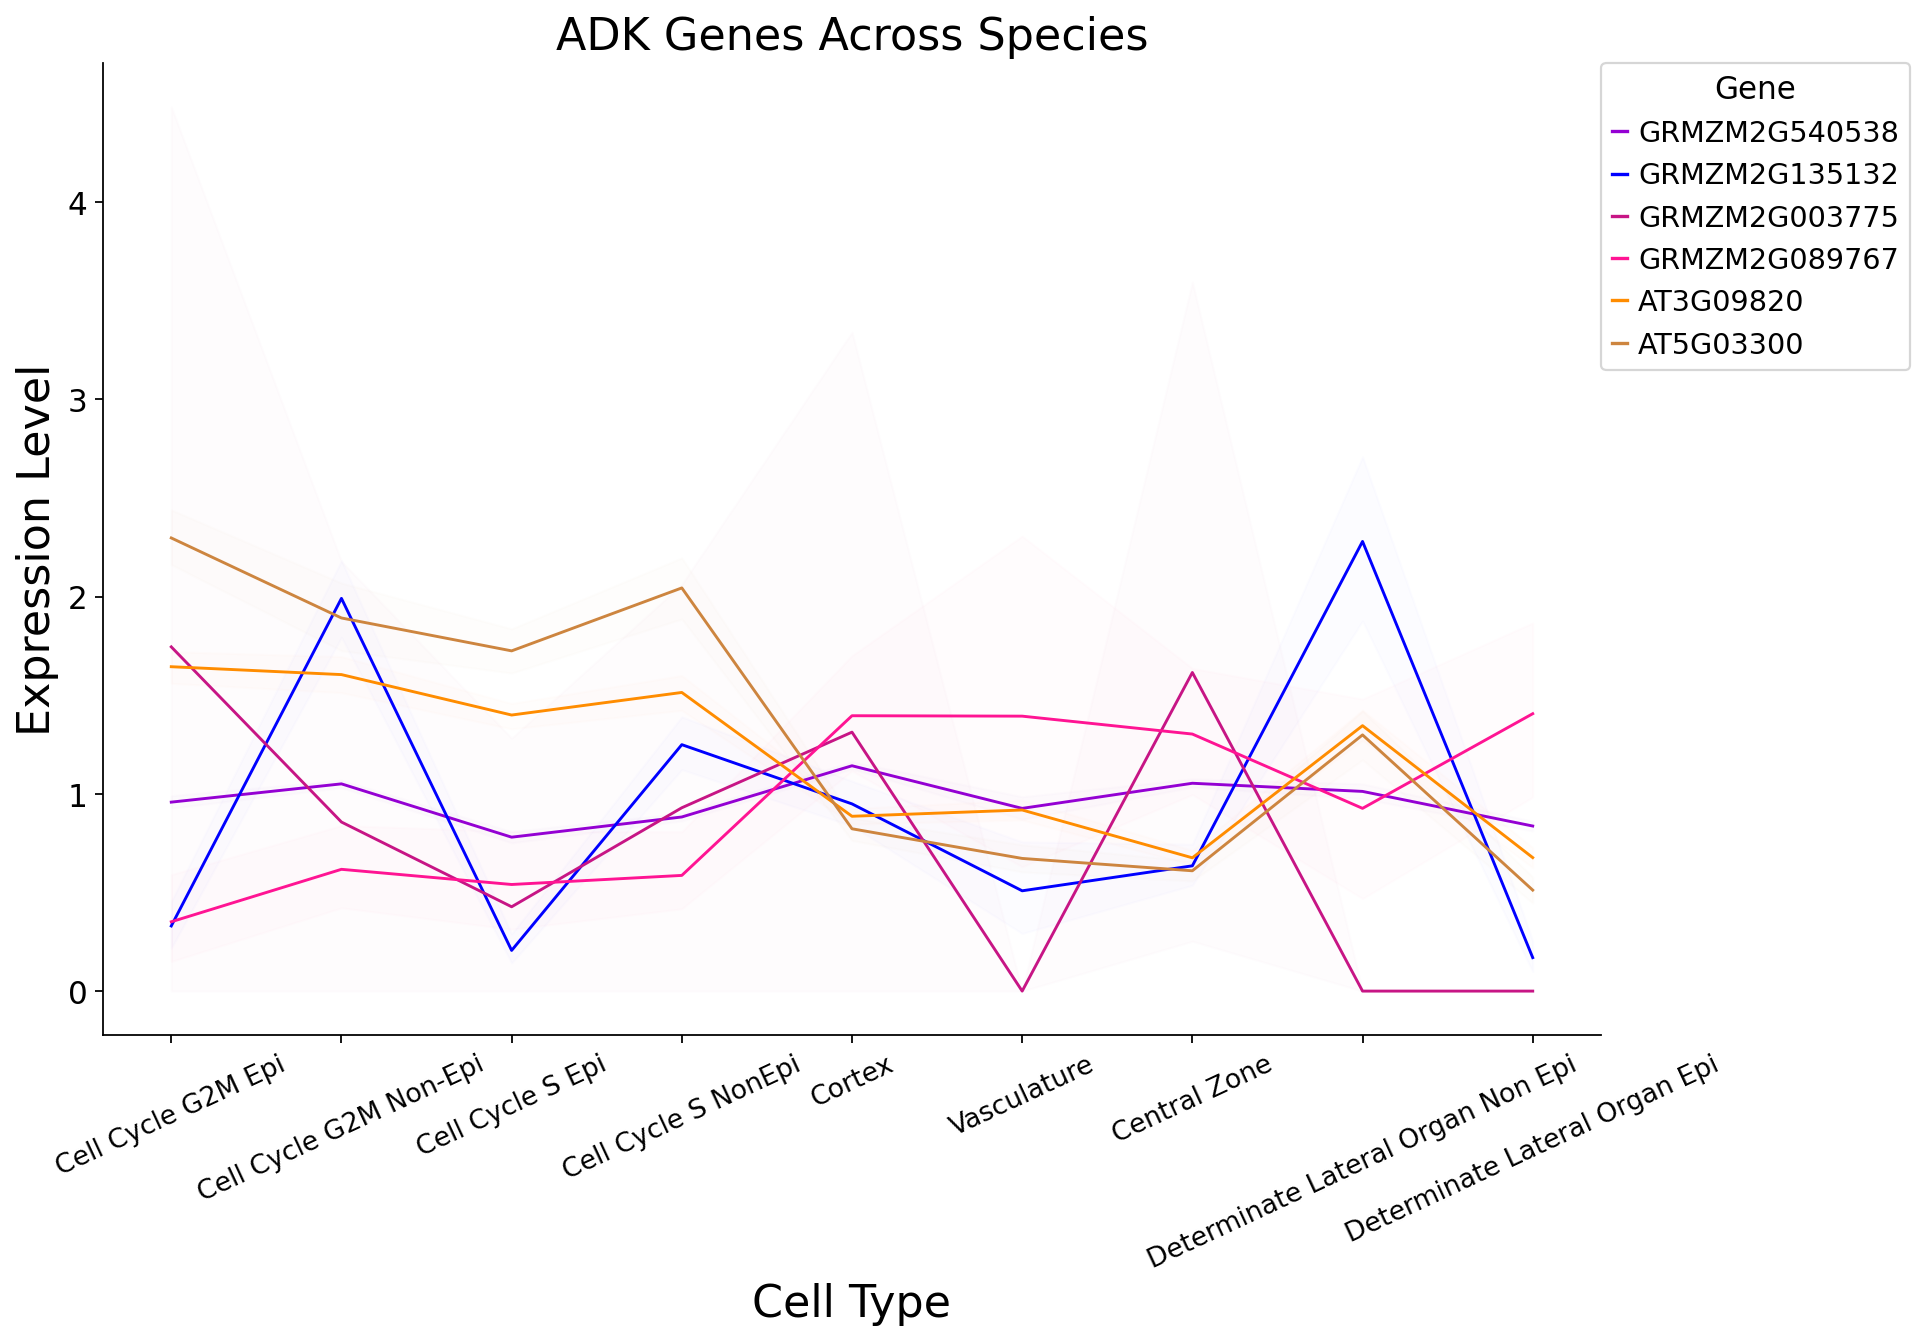

In [75]:
fig, ax = plt.subplots(figsize = (12,8))
fig.patch.set_facecolor('white')
ax = sns.lineplot(data = one_centered_total_df, x = 'Cell Type Number',y = 'Expression Level',hue = 'Gene', hue_order=['GRMZM2G540538','GRMZM2G135132','GRMZM2G003775','GRMZM2G089767','AT3G09820','AT5G03300'], palette= ['darkviolet','blue','mediumvioletred','deeppink','darkorange','peru'], err_kws= {'alpha':.01,}, linewidth = 1.3) #style = 'Gene', dashes = Truehue_order=['GRMZM2G540538','GRMZM2G135132','GRMZM2G003775','GRMZM2G089767','AT3G09820','AT5G03300'], palette= ['darkviolet','darkviolet','darkviolet','darkviolet','darkorange','darkorange']
plt.ylabel("Expression Level", fontsize = 20)
plt.xlabel("Cell Type", fontsize = 20)
sns.despine()

ax.grid(False)
ax.spines["bottom"].set_color("black")
ax.spines["left"].set_color("black")
ax.set_xticks([0,1,2,3,4,5,6,7,8], labels=list_of_cell_types)
#ax.set_xticklabels(['Phloem 1','Xylem','Endodermis 2','Phloem 2','Endodermis','Atrichoblasts/Columella','Trichoblasts','Meristematic/QC','Cortex'])
#plt.xlim((-7,7))
# plt.ylim((0, 1250))
plt.title("ADK Genes Across Species", fontsize = 20)
plt.xticks(fontsize = 12, rotation = 25)
plt.legend(bbox_to_anchor=(1, 1), loc='upper left', borderaxespad=0, title = 'Gene')

# replace legend using handles and labels from above

#plt.yticks(fontsize = 11)

In [76]:
#### PFKB gene Melter


total_gene_df = pd.DataFrame(columns = ['Gene','Expression Level','Cell Type'])

one_centered_total_df = pd.DataFrame(columns = ['Gene','Expression Level','Cell Type'])


full_genes_means = []
full_genes_stds = []
for cell_type in list_of_cell_types:
    print(cell_type)
    current_type_anndata = labeled_maize_single_cell[labeled_maize_single_cell.obs['Cell Type'] == cell_type,:]
    current_type_anndata = current_type_anndata[:,current_type_anndata.var_names.isin(list_of_PFKB_genes_in_maize)]


    panda_version_of_current_data = pd.DataFrame(columns = current_type_anndata.var_names, index = current_type_anndata.obs.index, data = current_type_anndata.X.todense())
    melted_genes = panda_version_of_current_data.melt(var_name = 'Gene',value_name= 'Expression Level')
    melted_genes['Cell Type'] = cell_type
    total_gene_df = pd.concat([total_gene_df,melted_genes])

    



    current_type_anndata = labeled_arabi_single_cell[labeled_arabi_single_cell.obs['Cell Type'] == cell_type,:]
    current_type_anndata = current_type_anndata[:,current_type_anndata.var_names.isin(arabidopsis_PFKB_genes)]

    panda_version_of_current_data = pd.DataFrame(columns = current_type_anndata.var_names, index = current_type_anndata.obs.index, data = current_type_anndata.X.todense())
    melted_genes = panda_version_of_current_data.melt(var_name = 'Gene',value_name= 'Expression Level')
    melted_genes['Cell Type'] = cell_type
    total_gene_df = pd.concat([total_gene_df,melted_genes])

Cell Cycle G2M Epi
Cell Cycle G2M Non-Epi
Cell Cycle S Epi
Cell Cycle S NonEpi
Cortex
Vasculature
Central Zone
Determinate Lateral Organ Non Epi
Determinate Lateral Organ Epi


In [77]:
total_gene_df['Cell Type Number'] = total_gene_df['Cell Type'].map(cell_type_number_mapper)

In [79]:
one_centered_total_df = total_gene_df.copy()

for gene in set(one_centered_total_df['Gene'].to_list()):
    all_gene_measurements = one_centered_total_df.loc[one_centered_total_df['Gene'] == gene]
    mean_centered_expression = all_gene_measurements['Expression Level']/all_gene_measurements['Expression Level'].mean()
    one_centered_total_df['Expression Level'].loc[one_centered_total_df['Gene'] == gene] = mean_centered_expression
one_centered_total_df = one_centered_total_df.reset_index()

/tmp/ipykernel_429716/2595593236.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  one_centered_total_df['Expression Level'].loc[one_centered_total_df['Gene'] == gene] = mean_centered_expression


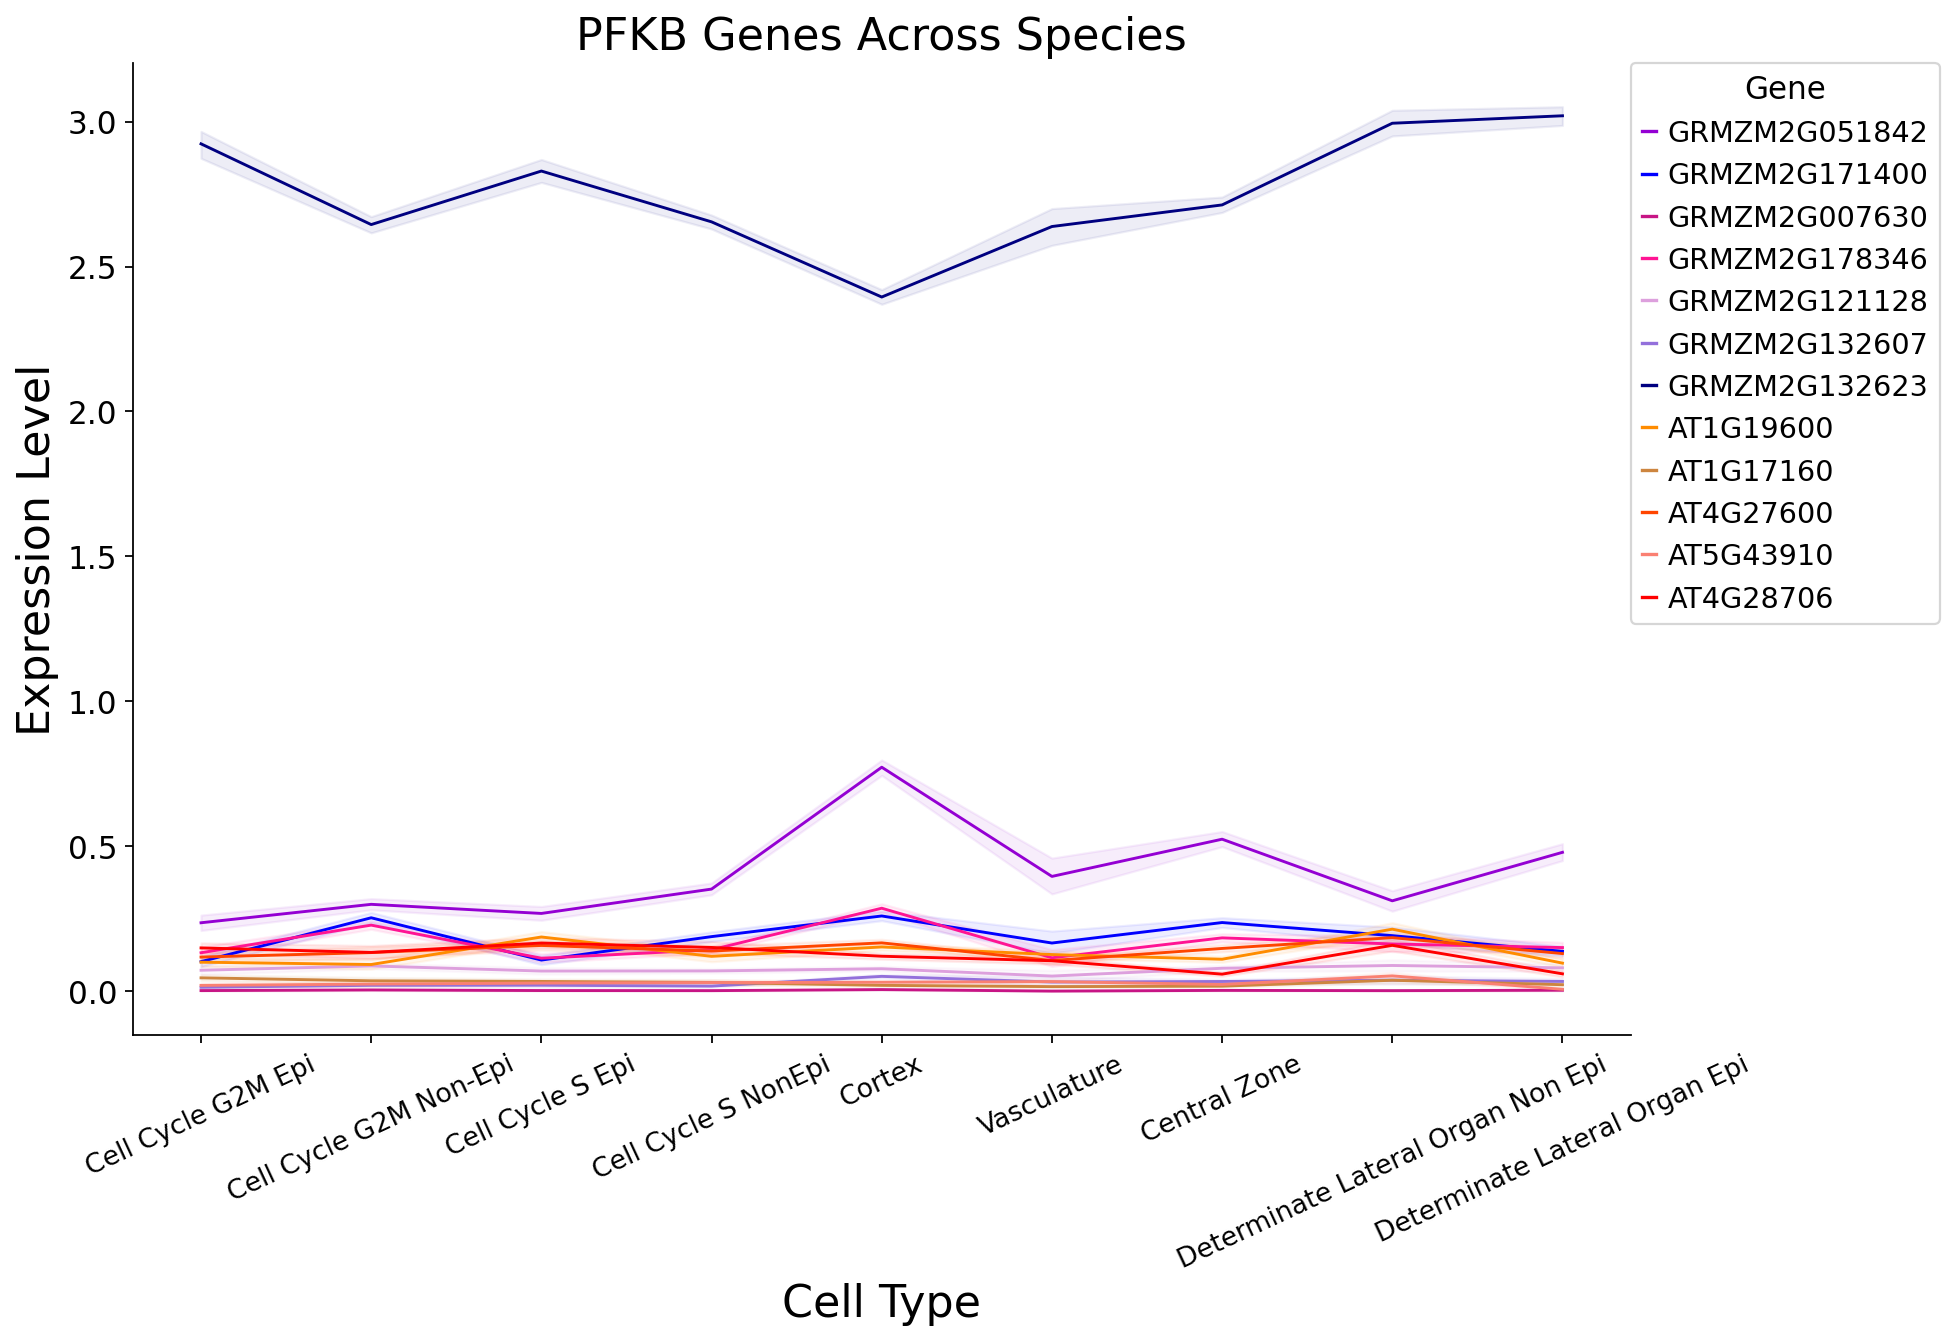

In [80]:
fig, ax = plt.subplots(figsize = (12,8))
fig.patch.set_facecolor('white')
ax = sns.lineplot(data = total_gene_df, x = 'Cell Type Number',y = 'Expression Level',hue = 'Gene', hue_order=['GRMZM2G051842','GRMZM2G171400','GRMZM2G007630','GRMZM2G178346','GRMZM2G121128','GRMZM2G132607','GRMZM2G132623','AT1G19600','AT1G17160','AT4G27600','AT5G43910','AT4G28706'], palette= ['darkviolet','blue','mediumvioletred','deeppink','plum','mediumpurple','navy','darkorange','peru','orangered','salmon','red'], err_kws= {'alpha':.07,}, linewidth = 1.3) #style = 'Gene', dashes = Truehue_order=['GRMZM2G540538','GRMZM2G135132','GRMZM2G003775','GRMZM2G089767','AT3G09820','AT5G03300'], palette= ['darkviolet','darkviolet','darkviolet','darkviolet','darkorange','darkorange']
plt.ylabel("Expression Level", fontsize = 20)
plt.xlabel("Cell Type", fontsize = 20)
sns.despine()

ax.grid(False)
ax.spines["bottom"].set_color("black")
ax.spines["left"].set_color("black")
ax.set_xticks([0,1,2,3,4,5,6,7,8], labels=list_of_cell_types)
#ax.set_xticklabels(['Phloem 1','Xylem','Endodermis 2','Phloem 2','Endodermis','Atrichoblasts/Columella','Trichoblasts','Meristematic/QC','Cortex'])
#plt.xlim((-7,7))
# plt.ylim((0, 1250))
plt.title("PFKB Genes Across Species", fontsize = 20)
plt.xticks(fontsize = 12, rotation = 25)
plt.legend(bbox_to_anchor=(1, 1), loc='upper left', borderaxespad=0, title = 'Gene')

# replace legend using handles and labels from above

#plt.yticks(fontsize = 11)

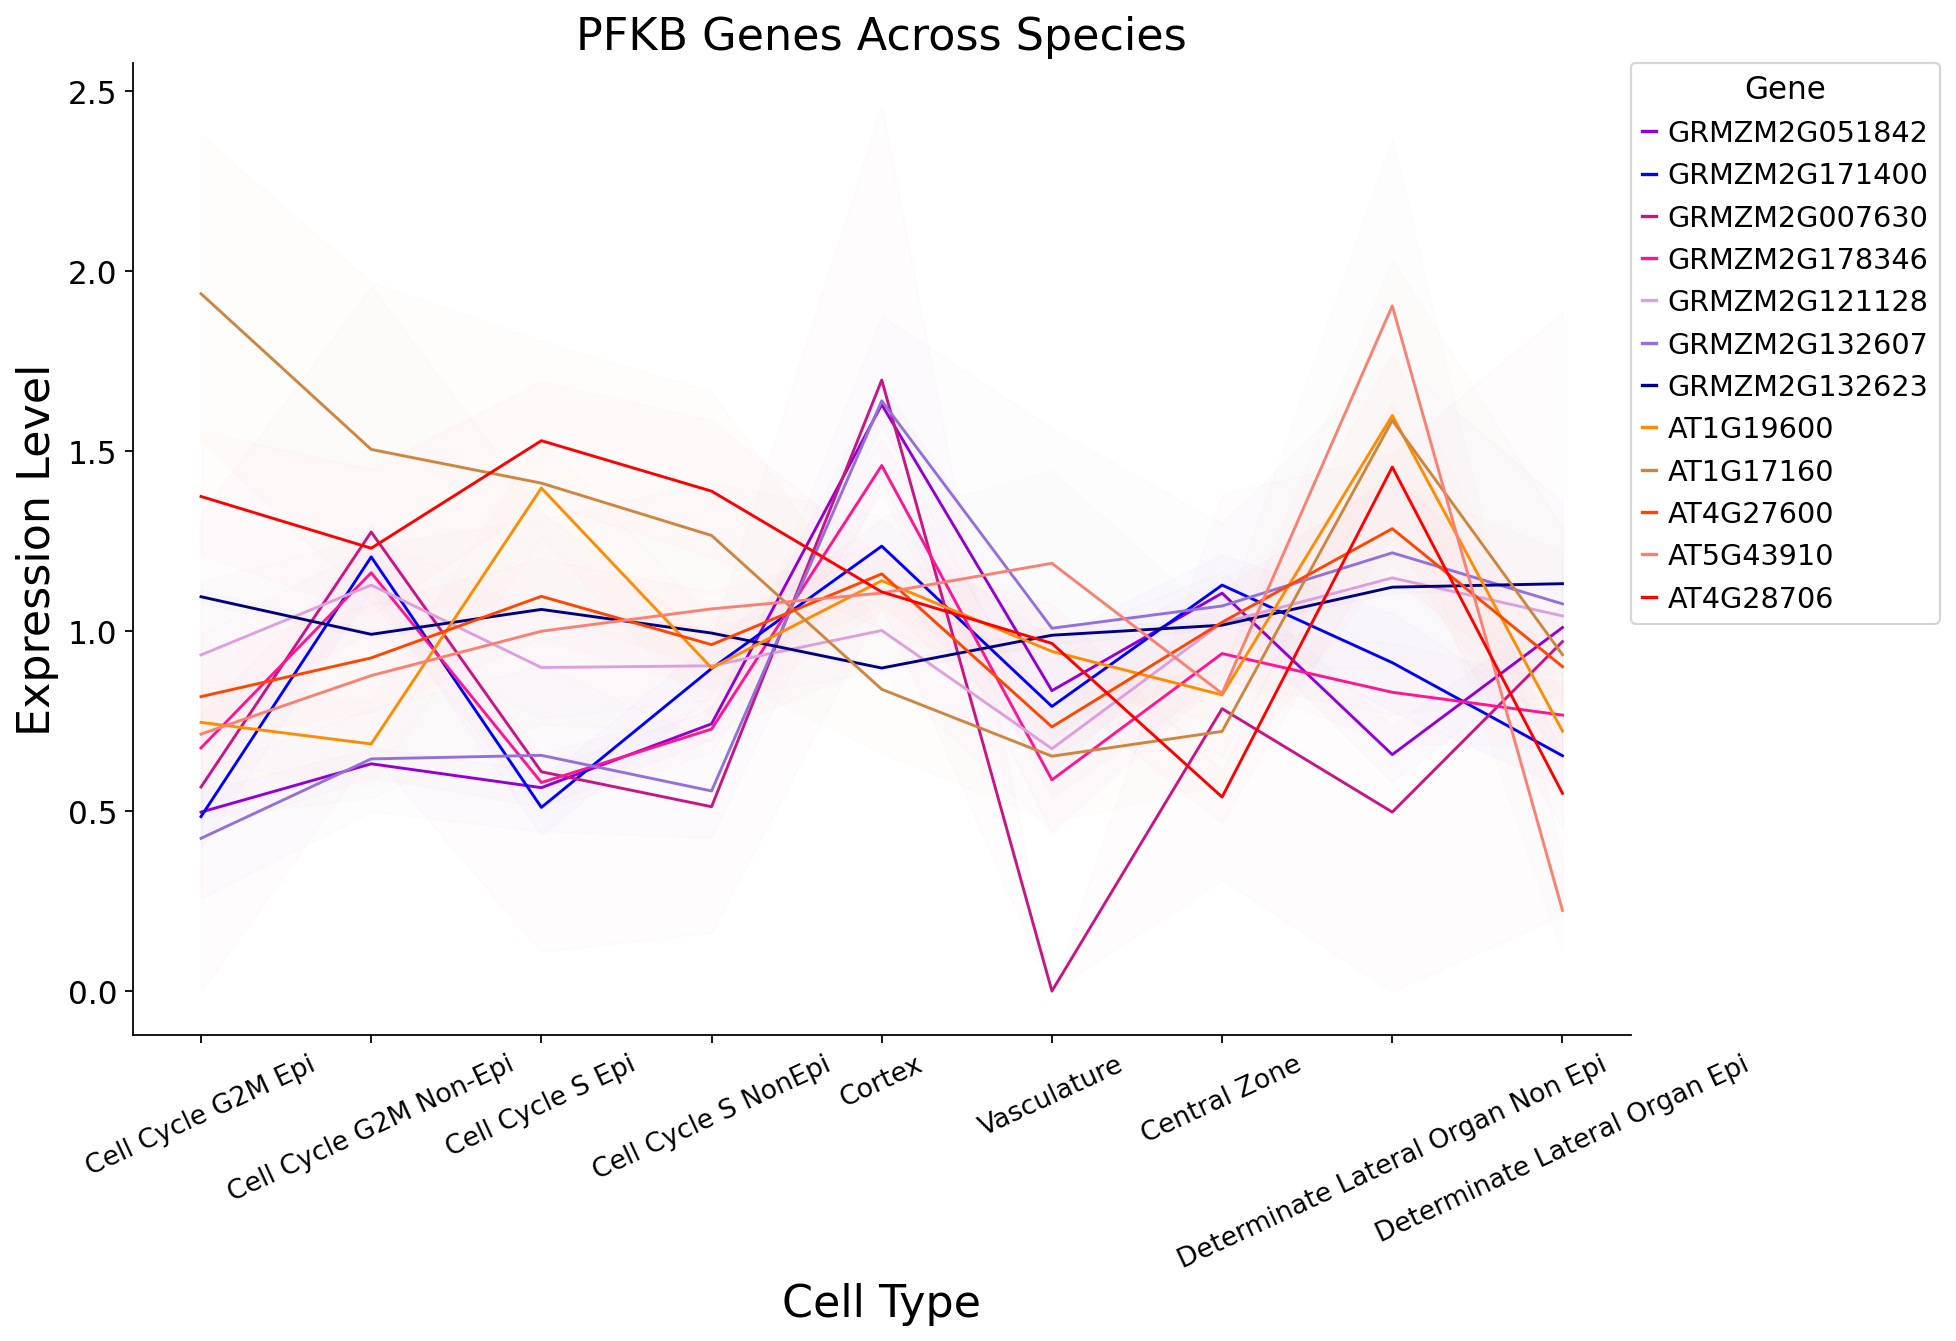

In [82]:
fig, ax = plt.subplots(figsize = (12,8))
fig.patch.set_facecolor('white')
ax = sns.lineplot(data = one_centered_total_df, x = 'Cell Type Number',y = 'Expression Level',hue = 'Gene', hue_order=['GRMZM2G051842','GRMZM2G171400','GRMZM2G007630','GRMZM2G178346','GRMZM2G121128','GRMZM2G132607','GRMZM2G132623','AT1G19600','AT1G17160','AT4G27600','AT5G43910','AT4G28706'], palette= ['darkviolet','blue','mediumvioletred','deeppink','plum','mediumpurple','navy','darkorange','peru','orangered','salmon','red'], err_kws= {'alpha':.01,}, linewidth = 1.3) #style = 'Gene', dashes = Truehue_order=['GRMZM2G540538','GRMZM2G135132','GRMZM2G003775','GRMZM2G089767','AT3G09820','AT5G03300'], palette= ['darkviolet','darkviolet','darkviolet','darkviolet','darkorange','darkorange']
plt.ylabel("Expression Level", fontsize = 20)
plt.xlabel("Cell Type", fontsize = 20)
sns.despine()

ax.grid(False)
ax.spines["bottom"].set_color("black")
ax.spines["left"].set_color("black")
ax.set_xticks([0,1,2,3,4,5,6,7,8], labels=list_of_cell_types)
#ax.set_xticklabels(['Phloem 1','Xylem','Endodermis 2','Phloem 2','Endodermis','Atrichoblasts/Columella','Trichoblasts','Meristematic/QC','Cortex'])
#plt.xlim((-7,7))
# plt.ylim((0, 1250))
plt.title("PFKB Genes Across Species", fontsize = 20)
plt.xticks(fontsize = 12, rotation = 25)
plt.legend(bbox_to_anchor=(1, 1), loc='upper left', borderaxespad=0, title = 'Gene')

# replace legend using handles and labels from above

#plt.yticks(fontsize = 11)

In [83]:
list_of_cell_types

['Cell Cycle G2M Epi',
 'Cell Cycle G2M Non-Epi',
 'Cell Cycle S Epi',
 'Cell Cycle S NonEpi',
 'Cortex',
 'Vasculature',
 'Central Zone',
 'Determinate Lateral Organ Non Epi',
 'Determinate Lateral Organ Epi']

In [84]:
cut_bad_maize_cells = ['Cell Cycle G2M Epi',
 'Cell Cycle G2M Non-Epi',
 'Cell Cycle S Epi',
 'Cell Cycle S NonEpi',
 'Determinate Lateral Organ Non Epi',
 'Determinate Lateral Organ Epi']

In [111]:
cell_type_number_mapper_cut_bad = {'Cell Cycle G2M Epi':0,
    'Cell Cycle G2M Non-Epi':1,
    'Cell Cycle S Epi':2,
    'Cell Cycle S NonEpi':3,
    'Determinate Lateral Organ Non Epi':4,
    'Determinate Lateral Organ Epi':5}

In [87]:
arabi_psuedobulked_means_cut_bad = arabi_psuedobulked_means.drop(index = ['Cortex','Vasculature','Central Zone'])
maize_psuedobulked_means_cut_bad = maize_psuedobulked_means.drop(index = ['Cortex','Vasculature','Central Zone'])

In [91]:
all_means_concat_cut_bad = pd.concat([maize_psuedobulked_means_cut_bad,arabi_psuedobulked_means_cut_bad], axis = 1)


In [92]:
full_correlations_cut_bad = all_means_concat_cut_bad.corr(method ='pearson')

In [117]:
adk_correlations = full_correlations_cut_bad.filter(list_of_ADK_genes_in_maize).filter(arabidopsis_adk_genes,axis = 0)
adk_correlations

_index,GRMZM2G540538,GRMZM2G135132,GRMZM2G003775,GRMZM2G089767
_index,,,,
AT3G09820,0.466777,0.361887,0.717710,-0.940963
AT5G03300,0.277813,0.114309,0.854228,-0.978967


In [93]:
maize_vs_arabi_correlations_cut_bad = full_correlations_cut_bad.filter(labeled_arabi_single_cell.var.index).drop(labeled_arabi_single_cell.var.index)

In [94]:
each_maize_gene_is_x_percentile_with_col_gene_cut_bad = maize_vs_arabi_correlations_cut_bad.rank(pct = True)
each_arabi_gene_is_x_percentile_with_row_gene_cut_bad = maize_vs_arabi_correlations_cut_bad.rank(pct = True, axis = 1)

In [103]:
arabi_pfkb_percentile = each_maize_gene_is_x_percentile_with_col_gene_cut_bad.filter(arabidopsis_PFKB_genes).filter(list_of_PFKB_genes_in_maize,axis = 0)
arabi_pfkb_percentile

_index,AT1G19600,AT1G17160,AT4G27600,AT5G43910,AT4G28706
_index,,,,,
GRMZM2G051842,0.352451,0.003356,0.464095,0.191384,0.037694
GRMZM2G171400,0.488843,0.436101,0.663593,0.787445,0.629772
GRMZM2G007630,0.091764,0.262015,0.215616,0.154428,0.252757
GRMZM2G178346,0.292922,0.533028,0.492716,0.608749,0.507985
GRMZM2G121128,0.659093,0.506694,0.777044,0.781323,0.460333
GRMZM2G132607,0.880980,0.168960,0.905543,0.774757,0.366577
GRMZM2G132623,0.793273,0.506067,0.695902,0.523181,0.389075


In [104]:
arabi_adk_percentile = each_maize_gene_is_x_percentile_with_col_gene_cut_bad.filter(arabidopsis_adk_genes).filter(list_of_ADK_genes_in_maize,axis = 0)
arabi_adk_percentile

_index,AT3G09820,AT5G03300
_index,,
GRMZM2G540538,0.838675,0.735736
GRMZM2G135132,0.767824,0.656917
GRMZM2G003775,0.947737,0.984104
GRMZM2G089767,0.019031,0.000996


In [105]:
maize_pfkb_percentile = each_arabi_gene_is_x_percentile_with_row_gene_cut_bad.filter(arabidopsis_PFKB_genes).filter(list_of_PFKB_genes_in_maize,axis = 0)
maize_pfkb_percentile

_index,AT1G19600,AT1G17160,AT4G27600,AT5G43910,AT4G28706
_index,,,,,
GRMZM2G051842,0.648162,0.059465,0.743788,0.542588,0.097034
GRMZM2G171400,0.401172,0.411257,0.720574,0.859719,0.535229
GRMZM2G007630,0.052742,0.279562,0.197928,0.106119,0.070140
GRMZM2G178346,0.221596,0.554718,0.475492,0.621042,0.369009
GRMZM2G121128,0.735474,0.628765,0.888021,0.868896,0.405533
GRMZM2G132607,0.849407,0.458820,0.922955,0.780539,0.481806
GRMZM2G132623,0.758552,0.604370,0.720438,0.604824,0.425567


In [106]:
maize_adk_percentile = each_arabi_gene_is_x_percentile_with_row_gene_cut_bad.filter(arabidopsis_adk_genes).filter(list_of_ADK_genes_in_maize,axis = 0)
maize_adk_percentile

_index,AT3G09820,AT5G03300
_index,,
GRMZM2G540538,0.854722,0.654204
GRMZM2G135132,0.784355,0.568937
GRMZM2G003775,0.783900,0.939899
GRMZM2G089767,0.060464,0.008722


In [107]:
averages = (maize_pfkb_percentile.stack()+arabi_pfkb_percentile.stack())/2
averages = averages.unstack()
averages

_index,AT1G19600,AT1G17160,AT4G27600,AT5G43910,AT4G28706
_index,,,,,
GRMZM2G051842,0.500307,0.031411,0.603941,0.366986,0.067364
GRMZM2G171400,0.445008,0.423679,0.692084,0.823582,0.582500
GRMZM2G007630,0.072253,0.270788,0.206772,0.130273,0.161449
GRMZM2G178346,0.257259,0.543873,0.484104,0.614895,0.438497
GRMZM2G121128,0.697284,0.567730,0.832532,0.825109,0.432933
GRMZM2G132607,0.865193,0.313890,0.914249,0.777648,0.424192
GRMZM2G132623,0.775912,0.555219,0.708170,0.564003,0.407321


In [108]:
averages.T

_index,GRMZM2G051842,GRMZM2G171400,GRMZM2G007630,GRMZM2G178346,GRMZM2G121128,GRMZM2G132607,GRMZM2G132623
_index,,,,,,,
AT1G19600,0.500307,0.445008,0.072253,0.257259,0.697284,0.865193,0.775912
AT1G17160,0.031411,0.423679,0.270788,0.543873,0.567730,0.313890,0.555219
AT4G27600,0.603941,0.692084,0.206772,0.484104,0.832532,0.914249,0.708170
AT5G43910,0.366986,0.823582,0.130273,0.614895,0.825109,0.777648,0.564003
AT4G28706,0.067364,0.582500,0.161449,0.438497,0.432933,0.424192,0.407321


In [109]:
averages = (maize_adk_percentile.stack()+arabi_adk_percentile.stack())/2
averages = averages.unstack()
averages

_index,AT3G09820,AT5G03300
_index,,
GRMZM2G540538,0.846699,0.694970
GRMZM2G135132,0.776089,0.612927
GRMZM2G003775,0.865819,0.962001
GRMZM2G089767,0.039748,0.004859


In [110]:
averages.T

_index,GRMZM2G540538,GRMZM2G135132,GRMZM2G003775,GRMZM2G089767
_index,,,,
AT3G09820,0.846699,0.776089,0.865819,0.039748
AT5G03300,0.694970,0.612927,0.962001,0.004859


In [112]:
cut_bad_maize_cells

['Cell Cycle G2M Epi',
 'Cell Cycle G2M Non-Epi',
 'Cell Cycle S Epi',
 'Cell Cycle S NonEpi',
 'Determinate Lateral Organ Non Epi',
 'Determinate Lateral Organ Epi']

In [113]:


total_gene_df = pd.DataFrame(columns = ['Gene','Expression Level','Cell Type'])

full_genes_means = []
full_genes_stds = []
for cell_type in cut_bad_maize_cells:
    print(cell_type)
    current_type_anndata = labeled_maize_single_cell[labeled_maize_single_cell.obs['Cell Type'] == cell_type,:]
    current_type_anndata = current_type_anndata[:,current_type_anndata.var_names.isin(list_of_ADK_genes_in_maize)]


    panda_version_of_current_data = pd.DataFrame(columns = current_type_anndata.var_names, index = current_type_anndata.obs.index, data = current_type_anndata.X.todense())
    
    melted_genes = panda_version_of_current_data.melt(var_name = 'Gene',value_name= 'Expression Level')
    melted_genes['Cell Type'] = cell_type
    total_gene_df = pd.concat([total_gene_df,melted_genes])





    current_type_anndata = labeled_arabi_single_cell[labeled_arabi_single_cell.obs['Cell Type'] == cell_type,:]
    current_type_anndata = current_type_anndata[:,current_type_anndata.var_names.isin(arabidopsis_adk_genes)]

    panda_version_of_current_data = pd.DataFrame(columns = current_type_anndata.var_names, index = current_type_anndata.obs.index, data = current_type_anndata.X.todense())
    melted_genes = panda_version_of_current_data.melt(var_name = 'Gene',value_name= 'Expression Level')
    melted_genes['Cell Type'] = cell_type
    total_gene_df = pd.concat([total_gene_df,melted_genes])

Cell Cycle G2M Epi
Cell Cycle G2M Non-Epi
Cell Cycle S Epi
Cell Cycle S NonEpi
Determinate Lateral Organ Non Epi
Determinate Lateral Organ Epi


In [114]:
total_gene_df['Cell Type Number'] = total_gene_df['Cell Type'].map(cell_type_number_mapper_cut_bad)

In [115]:
cut_bad_maize_cells

['Cell Cycle G2M Epi',
 'Cell Cycle G2M Non-Epi',
 'Cell Cycle S Epi',
 'Cell Cycle S NonEpi',
 'Determinate Lateral Organ Non Epi',
 'Determinate Lateral Organ Epi']

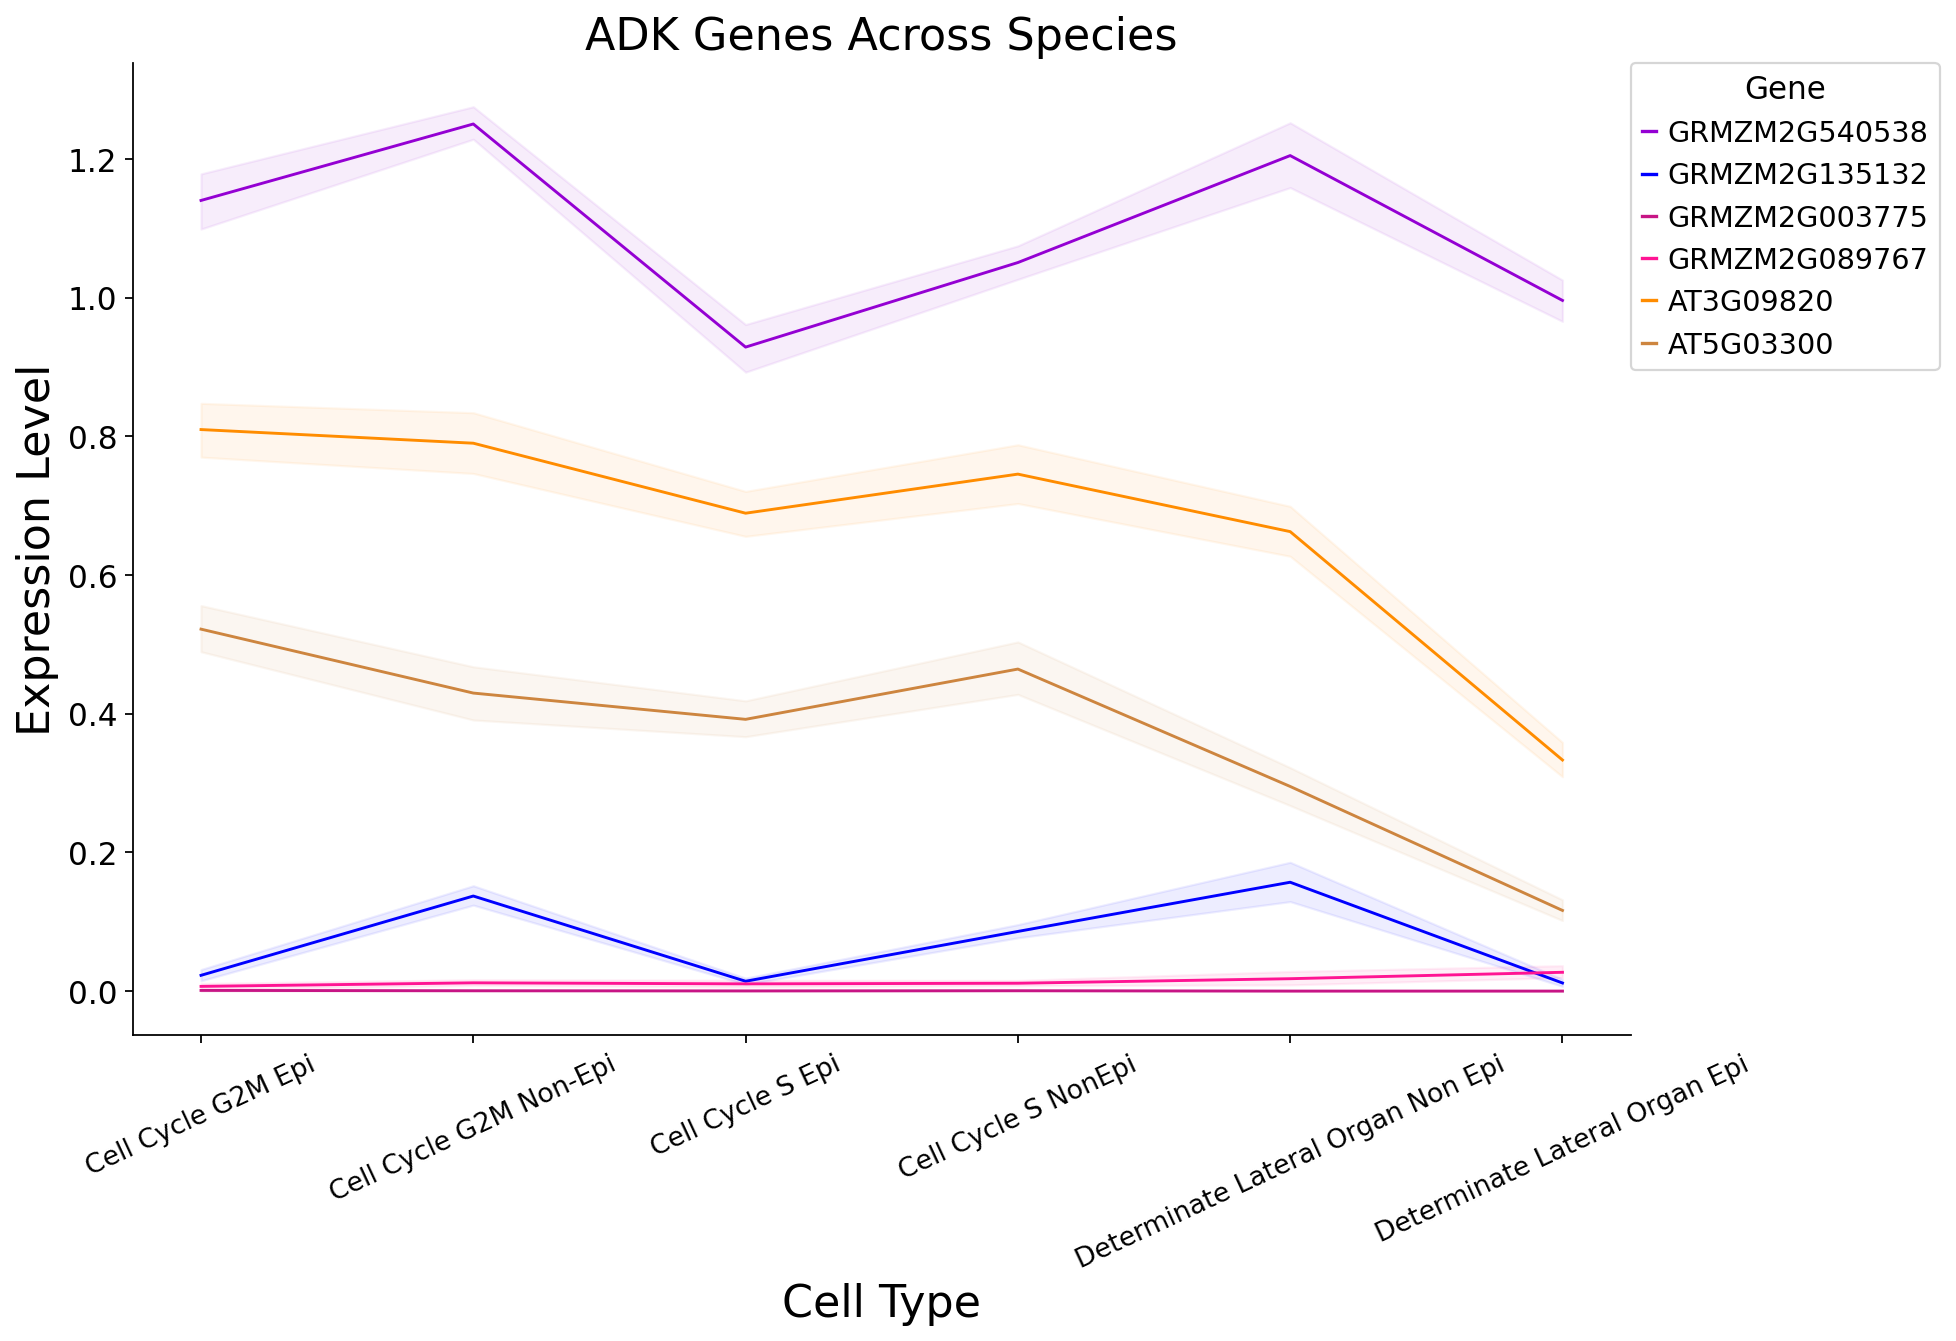

In [116]:
fig, ax = plt.subplots(figsize = (12,8))
fig.patch.set_facecolor('white')
ax = sns.lineplot(data = total_gene_df, x = 'Cell Type Number',y = 'Expression Level',hue = 'Gene', hue_order=['GRMZM2G540538','GRMZM2G135132','GRMZM2G003775','GRMZM2G089767','AT3G09820','AT5G03300'], palette= ['darkviolet','blue','mediumvioletred','deeppink','darkorange','peru'], err_kws= {'alpha':.07,}, linewidth = 1.3) #style = 'Gene', dashes = Truehue_order=['GRMZM2G540538','GRMZM2G135132','GRMZM2G003775','GRMZM2G089767','AT3G09820','AT5G03300'], palette= ['darkviolet','darkviolet','darkviolet','darkviolet','darkorange','darkorange']
plt.ylabel("Expression Level", fontsize = 20)
plt.xlabel("Cell Type", fontsize = 20)
sns.despine()

ax.grid(False)
ax.spines["bottom"].set_color("black")
ax.spines["left"].set_color("black")
ax.set_xticks([0,1,2,3,4,5], labels=cut_bad_maize_cells)
#ax.set_xticklabels(['Phloem 1','Xylem','Endodermis 2','Phloem 2','Endodermis','Atrichoblasts/Columella','Trichoblasts','Meristematic/QC','Cortex'])
#plt.xlim((-7,7))
# plt.ylim((0, 1250))
plt.title("ADK Genes Across Species", fontsize = 20)
plt.xticks(fontsize = 12, rotation = 25)
plt.legend(bbox_to_anchor=(1, 1), loc='upper left', borderaxespad=0, title = 'Gene')

# replace legend using handles and labels from above

#plt.yticks(fontsize = 11)

In [ ]:
maize_correlations  = maize_psuedobulked_means.corr(method= 'pearson')

In [ ]:
pd.DataFrame(data = labeled_maize_single_cell.X.todense()).melt().sample(n = 10000)

In [ ]:
ax = sns.histplot(data = maize_correlations.melt().sample(n = 10000), x = 'value')

In [ ]:
ax = sns.histplot(data = maize_correlations.melt().sample(n = 10000), x = 'value')